# **ML CHECKLIST**

# **1. Análisis univariante de los datos**



**1.1 Tamaño del Dataset (tamaño en memoria, número de registros y atributos, etc.)**

In [19]:
# PASO 1: Cargar las herramientas necesarias
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas
import matplotlib.pyplot as plt # Librería para la visualización de datos
import seaborn as sns # Librería para la visualización de datos
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder, OneHotEncoder # Librería para crear modelos de ML
import sys
import os
import importlib
print("=== INICIO DEL ANÁLISIS ===")
print()

=== INICIO DEL ANÁLISIS ===



In [20]:
# PASO 2: Cargar los datos
print("1. CARGANDO DATOS...")
datos = pd.read_csv("https://www.dropbox.com/s/sxl5bpi2620p496/sample_mmp.csv?dl=1")
print(f"   ✓ Datos cargados: {len(datos)} filas, {len(datos.columns)} columnas")
print()

1. CARGANDO DATOS...


/tmp/ipython-input-3920787428.py:3: DtypeWarning: Columns (29,42) have mixed types. Specify dtype option on import or set low_memory=False.
  datos = pd.read_csv("https://www.dropbox.com/s/sxl5bpi2620p496/sample_mmp.csv?dl=1")


   ✓ Datos cargados: 500000 filas, 84 columnas



In [21]:
datos.shape

(500000, 84)

# **Clave primaria: MachineIdentifer**
# **Target: HasDetection**


**1.2 Visualización directa de los datos (head)**

In [22]:
# PASO 3: Ver primeras filas
print("2. PRIMERAS 5 FILAS:")
print(datos.head())
print()

2. PRIMERAS 5 FILAS:
   Unnamed: 0                 MachineIdentifier   ProductName EngineVersion  \
0     8427007  f1cd864e97bae82bdf96523e1a539121  win8defender   1.1.15100.1   
1     8829090  fd5ba6f5b75325ec0423a6c67cc75942  win8defender   1.1.15100.1   
2     2731904  4e628391e7cc7c482fb3286f486dbd25  win8defender   1.1.15100.1   
3     1359513  270a2e9d028144a4df12a9e3da79fba5  win8defender   1.1.15200.1   
4      236059  06ca8fa8d32c2abdc5b3577d676b3269  win8defender   1.1.15200.1   

        AppVersion  AvSigVersion  IsBeta  RtpStateBitfield  IsSxsPassiveMode  \
0  4.18.1807.18075  1.273.1234.0       0               7.0                 0   
1  4.18.1807.18075  1.273.1282.0       0               7.0                 0   
2   4.9.10586.1106   1.273.781.0       0               7.0                 0   
3  4.18.1807.18075  1.275.1639.0       0               7.0                 0   
4  4.18.1807.18075   1.275.511.0       0               7.0                 0   

   DefaultBrowsersIdent

In [23]:
"""
  Descripcion de las Columnas del DataSet.
    Los nombres de columnas no disponibles o autodocumentados están marcados con "NA".

MachineIdentifier                     Identificación de máquina individual
ProductName                           Información del estado del W.defender, por ejemplo, win8defender
EngineVersion                         Información del estado del W.defender, por ejemplo, 1.1.12603.0
AppVersion                            Información del estado del W.defender, por ejemplo, 4.9.10586.0
AvSigVersion                          Información del estado del W.defender, por ejemplo, 1.217.1014.0
IsBeta                                Información del estado del W.defender, por ejemplo, falso
RtpStateBitfield                      N / A
IsSxsPassiveMode                      N / A
DefaultBrowsersIdentifier             ID del navegador predeterminado de la máquina
AVProductStatesIdentifier             ID para la configuración específica del software antivirus de un usuario
AVProductsInstalled                   N / A
AVProductsEnabled                     N / A
HasTpm                                Verdadero si la máquina tiene tpm
CountryIdentifier                     Identificación del país en el que se encuentra la máquina
CityIdentifier                        Identificación de la ciudad donde se encuentra la máquina
OrganizationIdentifier                ID de la organización a la que pertenece la máquina, el ID de la organización se asigna tanto a empresas específicas como a industrias amplias
GeoNameIdentifier                     Identificación de la región geográfica en la que se encuentra una máquina
LocaleEnglishNameIdentifier           Nombre en inglés del ID de configuración regional del usuario actual
Platform                              Calcula el nombre de la plataforma (de las propiedades relacionadas con el sistema operativo y la propiedad del procesador)
Processor                             Esta es la arquitectura de procesos del sistema operativo instalado.
OsVer                                 Versión del sistema operativo actual
OsBuild                               Construcción del sistema operativo actual
OsSuite                               Máscara de suite de productos para el sistema operativo actual.
OsPlatformSubRelease                  Devuelve la sub-release de la plataforma del sistema operativo (Windows Vista, Windows 7, Windows 8, TH1, TH2)
OsBuildLab                            Laboratorio de compilación que generó el sistema operativo actual. Ejemplo: 9600.17630.amd64fre.winblue_r7.150109-2022
SkuEdition                            El objetivo de esta función es usar el tipo de producto definido en MSDN para asignarlo a un nombre de "Edición de SKU" útil para los informes de población.
                                        Los tipos de producto válidos se definen en %sdxroot%\data\windowseditions.xml. Esta API se ha utilizado desde Vista y Server 2008,
                                        por lo que muchos tipos de producto no son compatibles con Windows 10. El valor de "Edición de SKU" es una cadena que pertenece a una de tres clases de resultados.
                                        El diseño debe gestionar cada clase.
IsProtectedEste                       campo se calcula a partir del campo "Productos antivirus" del informe de Spynet. Devuelve:
                                        a. VERDADERO  si hay al menos un producto antivirus activo y actualizado ejecutándose en este equipo.
                                        b. FALSO      si no hay ningún producto antivirus activo en este equipo, o si el antivirus está activo, pero no recibe las últimas actualizaciones.
                                        c. NULL       si no hay productos antivirus en el informe. Devuelve: Si un equipo está protegido.
AutoSampleOptIn                       Este es el valor SubmitSamplesConsent pasado desde el servicio, disponible en CAMP 9+
PuaMode                               Modo Pua habilitado desde el servicio
SMode                                 Este campo se establece como verdadero cuando se sabe que el dispositivo está en "Modo S", como en el modo S de Windows 10, donde solo se pueden instalar aplicaciones de Microsoft Store.
IeVerIdentifier                       N / A
SmartScreen                           Este es el valor de la cadena SmartScreen habilitado del registro. Se obtiene verificando en orden HKLM\SOFTWARE\Policies\Microsoft\Windows\System\SmartScreenEnabled y HKLM\SOFTWARE\Microsoft\Windows\CurrentVersion\Explorer\SmartScreenEnabled. Si el valor existe, pero está vacío, se envía el valor "ExistsNotSet" en la telemetría.
Firewall                              Este atributo es verdadero (1) para Windows 8.1 y superior si el firewall de Windows está habilitado, según lo informado por el servicio.
UacLuaenable                          Este atributo indica si el tipo de usuario "Administrador en modo de aprobación de administrador" está deshabilitado o habilitado en el Control de cuentas de usuario (UAC). El valor se obtiene leyendo la clave de registro HKLM\SOFTWARE\Microsoft\Windows\CurrentVersion\Policies\System\EnableLUA.
Census_MDC2FormFactor                 Una agrupación basada en una combinación de características de hardware a nivel de Censo de Dispositivos. La lógica empleada para definir el factor de forma se basa en estándares empresariales e industriales y se alinea con la percepción que las personas tienen de sus dispositivos. (Ejemplos: smartphone, tablet pequeña, todo en uno, convertible, etc.)
Census_DeviceFamily                   También conocida como DeviceClass. Indica el tipo de dispositivo al que está destinada una edición del sistema operativo. Valores de ejemplo: Windows.Desktop, Windows.Mobile e iOS.Phone
Census_OEMNameIdentifier              N / A
Census_OEMModelIdentifier             N / A
Census_ProcessorCoreCount             Número de núcleos lógicos en el procesador
Census_ProcessorManufacturerIdentifier    N / A
Census_ProcessorModelIdentifier           N / A
Census_ProcessorClass                 Clasificación de procesadores en alto/medio/bajo. Inicialmente utilizado para SKU de nivel de precios. Ya no se mantiene ni actualiza.
Census_PrimaryDiskTotalCapacity       Cantidad de espacio en disco en el disco principal de la máquina en MB
Census_PrimaryDiskTypeName            Nombre descriptivo del tipo de disco principal: HDD o SSD
Census_SystemVolumeTotalCapacity      El tamaño de la partición en la que está instalado el volumen del sistema en MB
Census_HasOpticalDiskDrive            Verdadero indica que la máquina tiene una unidad de disco óptico (CD/DVD)
Census_TotalPhysicalRAM               Recupera la RAM física en MB
Census_ChassisTypeName                Recupera una representación numérica del tipo de chasis de la máquina. Un valor de 0 significa xx.
Census_InternalPrimaryDiagonalDisplaySizeInInches       Recupera la longitud diagonal física en pulgadas de la pantalla principal
--Census_InternalPrimaryDisplayResolutionHorizontal       Recupera el número de píxeles en la dirección horizontal de la pantalla interna.
--Census_InternalPrimaryDisplayResolutionVertical         Recupera el número de píxeles en la dirección vertical de la pantalla interna
Census_PowerPlatformRoleName          Indica el perfil de administración de energía preferido por el OEM. Este valor ayuda a identificar el formato básico del dispositivo.
Census_InternalBatteryType            N / A
Census_InternalBatteryNumberOfCharges N / A
Census_OSVersion                      Versión numérica del sistema operativo Ejemplo - 10.0.10130.0
Census_OSArchitecture                 Arquitectura en la que se basa el sistema operativo. Derivado de OSVersionFull. Ejemplo: amd64
Census_OSBranch                       Rama del sistema operativo extraída de OsVersionFull. Ejemplo: OsBranch = fbl_partner_eeap donde OsVersion = 6.4.9813.0.amd64fre fbl_partner_eeap.140810-0005
Census_OSBuildNumber                  Número de compilación del sistema operativo extraído de OsVersionFull. Ejemplo: OsBuildNumber = 10512 o 10240
Census_OSBuildRevision                Revisión de compilación del sistema operativo extraída de OsVersionFull. Ejemplo: OsBuildRevision = 1000 o 16458
Census_OSEdition                      Edición del sistema operativo actual. Obtenido de HKLM\Software\Microsoft\Windows NT\CurrentVersion@EditionID en el registro. Ejemplo: Enterprise
Census_OSSkuName                      Nombre descriptivo de la edición del sistema operativo (actualmente solo Windows)
Census_OSInstallTypeName              Descripción amigable de qué instalación se utilizó en la máquina, es decir, limpia
Census_OSInstallLanguageIdentifier    N / A
Census_OSUILocaleIdentifier           N / A
Census_OSWUAutoUpdateOptionsName      Nombre descriptivo de la configuración de actualización automática de WindowsUpdate en la máquina.
Census_IsPortableOperatingSystem      Indica si el sistema operativo se inicia y se ejecuta a través de Windows-To-Go en una memoria USB.
Census_GenuineStateName               Nombre descriptivo de OSGenuineStateID. 0 = Genuino
Census_ActivationChannel              Clave de licencia minorista o clave de licencia por volumen para una máquina.
Census_IsFlightingInternal            N / A
Census_IsFlightsDisabled              Indica si la máquina está participando en el vuelo.
Census_FlightRing                     El anillo para el que el usuario del dispositivo desea recibir vuelos. Este podría ser diferente del anillo del sistema operativo instalado si el usuario cambia el anillo después de obtener un vuelo de otro anillo.
Census_ThresholdOptIn                 N / A
Census_FirmwareManufacturerIdentifier N / A
Census_FirmwareVersionIdentifier      N / A
Census_IsSecureBootEnabled            Indica si el modo de arranque seguro está habilitado.
Census_IsWIMBootEnabled               N / A
Census_IsVirtualDevice                Identifica una máquina virtual (modelo de aprendizaje automático)
Census_IsTouchEnabled                 ¿Es este un dispositivo táctil?
Census_IsPenCapable                   ¿El dispositivo es capaz de introducir datos con lápiz?
Census_IsAlwaysOnAlwaysConnectedCapable     Recupera información sobre si la batería permite que el dispositivo esté AlwaysOnAlwaysConnected.
Wdft_IsGamer                          Indica si el dispositivo es un dispositivo de juego o no en función de su combinación de hardware.
Wdft_RegionIdentifier                 N / A
"""

<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-436969907.py:31: SyntaxWarning: invalid escape sequence '\d'
  Los tipos de producto válidos se definen en %sdxroot%\data\windowseditions.xml. Esta API se ha utilizado desde Vista y Server 2008,


' \n  Descripcion de las Columnas del DataSet.\n    Los nombres de columnas no disponibles o autodocumentados están marcados con "NA".\n\nMachineIdentifier                     Identificación de máquina individual\nProductName                           Información del estado del W.defender, por ejemplo, win8defender\nEngineVersion                         Información del estado del W.defender, por ejemplo, 1.1.12603.0\nAppVersion                            Información del estado del W.defender, por ejemplo, 4.9.10586.0\nAvSigVersion                          Información del estado del W.defender, por ejemplo, 1.217.1014.0\nIsBeta                                Información del estado del W.defender, por ejemplo, falso\nRtpStateBitfield                      N / A\nIsSxsPassiveMode                      N / A\nDefaultBrowsersIdentifier             ID del navegador predeterminado de la máquina\nAVProductStatesIdentifier             ID para la configuración específica del software antivirus de 

In [24]:
datos

,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,8427007,f1cd864e97bae82bdf96523e1a539121,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1234.0,0,7.0,0,NaN,...,19951.0,0,NaN,0.0,0,0,0.0,0.0,11.0,1
1,8829090,fd5ba6f5b75325ec0423a6c67cc75942,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1282.0,0,7.0,0,NaN,...,48753.0,0,0.0,0.0,0,0,0.0,1.0,3.0,0
2,2731904,4e628391e7cc7c482fb3286f486dbd25,win8defender,1.1.15100.1,4.9.10586.1106,1.273.781.0,0,7.0,0,NaN,...,33111.0,1,0.0,0.0,1,1,0.0,0.0,15.0,0
3,1359513,270a2e9d028144a4df12a9e3da79fba5,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1639.0,0,7.0,0,NaN,...,48473.0,1,NaN,0.0,0,0,0.0,0.0,15.0,1
4,236059,06ca8fa8d32c2abdc5b3577d676b3269,win8defender,1.1.15200.1,4.18.1807.18075,1.275.511.0,0,7.0,0,NaN,...,4343.0,1,NaN,0.0,1,0,0.0,1.0,13.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,5826339,a739cacc292f3f1e745827c1ca6c6ada,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1090.0,0,7.0,0,NaN,...,33088.0,1,0.0,0.0,1,0,0.0,1.0,10.0,0
499996,5740034,a4c232d528d98343e8f1b73650da7b82,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1620.0,0,7.0,0,NaN,...,NaN,0,NaN,0.0,0,0,0.0,0.0,15.0,0
499997,8819786,fd16cd542d660848d272e4552bcccb1e,win8defender,1.1.15300.5,4.13.17134.112,1.275.1343.0,0,7.0,0,NaN,...,41727.0,0,NaN,0.0,0,0,0.0,0.0,8.0,0
499998,8713685,fa0841f8f6147de7c3d287e05270ed42,win8defender,1.1.15100.1,4.14.17639.18041,1.273.483.0,0,7.0,0,NaN,...,11947.0,0,NaN,0.0,0,0,0.0,0.0,1.0,0


**1.3 Tipo de atributos disponibles (numéricos, categóricos)**

In [25]:
# PASO 4: Tipo de datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 84 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   Unnamed: 0                                         500000 non-null  int64  
 1   MachineIdentifier                                  500000 non-null  object 
 2   ProductName                                        500000 non-null  object 
 3   EngineVersion                                      500000 non-null  object 
 4   AppVersion                                         500000 non-null  object 
 5   AvSigVersion                                       500000 non-null  object 
 6   IsBeta                                             500000 non-null  int64  
 7   RtpStateBitfield                                   498168 non-null  float64
 8   IsSxsPassiveMode                                   500000 non-null  int64 

In [26]:
# Contar tipos
numericas = len(datos.select_dtypes(include=['int64', 'float64']).columns)
categoricas = len(datos.select_dtypes(include=['object', 'category', 'bool']).columns)
print(f"   Total numéricas: {numericas}")
print(f"   Total categóricas (texto): {categoricas}")
print()

   Total numéricas: 54
   Total categóricas (texto): 30



**1.4 Estadísticos descriptivos (valores medios, dispersión, percentiles, etc.)**

In [27]:
# PASO 5: Estadísticas básicas
print("4. ESTADÍSTICAS BÁSICAS:")
print("-" * 40)
print("Estadísticas de columnas numéricas:")
print(datos.describe())
print()

4. ESTADÍSTICAS BÁSICAS:
----------------------------------------
Estadísticas de columnas numéricas:
         Unnamed: 0         IsBeta  RtpStateBitfield  IsSxsPassiveMode  \
count  5.000000e+05  500000.000000     498168.000000     500000.000000   
mean   4.458888e+06       0.000002          6.846207          0.017242   
std    2.575619e+06       0.001414          1.023049          0.130172   
min    2.000000e+00       0.000000          0.000000          0.000000   
25%    2.227692e+06       0.000000          7.000000          0.000000   
50%    4.461368e+06       0.000000          7.000000          0.000000   
75%    6.690936e+06       0.000000          7.000000          0.000000   
max    8.921471e+06       1.000000         35.000000          1.000000   

       DefaultBrowsersIdentifier  AVProductStatesIdentifier  \
count               24061.000000              498062.000000   
mean                 1652.824529               47850.908413   
std                  1004.754276          

**1.5 Número de valores nulos**

In [28]:
# PASO 6: Valores faltantes
print("5. VALORES FALTANTES:")
nulos = datos.isnull().sum()
columnas_con_nulos = nulos[nulos > 0]

if len(columnas_con_nulos) > 0:
    print("Columnas con valores faltantes:")
    for col, cant in columnas_con_nulos.items():
        porc = (cant / len(datos)) * 100
        print(f"   {col}: {cant} faltantes ({porc:.1f}%)")
else:
    print("   ✓ No hay valores faltantes")
print()

5. VALORES FALTANTES:
Columnas con valores faltantes:
   RtpStateBitfield: 1832 faltantes (0.4%)
   DefaultBrowsersIdentifier: 475939 faltantes (95.2%)
   AVProductStatesIdentifier: 1938 faltantes (0.4%)
   AVProductsInstalled: 1938 faltantes (0.4%)
   AVProductsEnabled: 1938 faltantes (0.4%)
   CityIdentifier: 18240 faltantes (3.6%)
   OrganizationIdentifier: 154563 faltantes (30.9%)
   GeoNameIdentifier: 16 faltantes (0.0%)
   OsBuildLab: 1 faltantes (0.0%)
   IsProtected: 1926 faltantes (0.4%)
   PuaMode: 499874 faltantes (100.0%)
   SMode: 29848 faltantes (6.0%)
   IeVerIdentifier: 3209 faltantes (0.6%)
   SmartScreen: 178596 faltantes (35.7%)
   Firewall: 5162 faltantes (1.0%)
   UacLuaenable: 623 faltantes (0.1%)
   Census_OEMNameIdentifier: 5381 faltantes (1.1%)
   Census_OEMModelIdentifier: 5764 faltantes (1.2%)
   Census_ProcessorCoreCount: 2347 faltantes (0.5%)
   Census_ProcessorManufacturerIdentifier: 2347 faltantes (0.5%)
   Census_ProcessorModelIdentifier: 2349 faltantes 

In [30]:
del datos['DefaultBrowsersIdentifier']    #Tiene el 95,2% ID del navegador predeterminado de la máquina

KeyError: 'DefaultBrowsersIdentifier'

In [31]:
del datos['Census_ProcessorClass']        #Tiene el 99,6% Clasificación de procesadores en alto/medio/bajo. Inicialmente utilizado para SKU de nivel de precios. Ya no se mantiene ni actualiza.

In [32]:
del datos['PuaMode']                      #Tiene el 100% Modo Pua habilitado desde el servicio

In [33]:
del datos['Census_IsFlightingInternal']   #Tiene el 83% N/A

In [34]:
del datos['Census_InternalBatteryType']   #Tiene el 71.1% N/A

In [35]:
del datos['Census_IsWIMBootEnabled']      #Tiene el 63.5% N/A

In [36]:
del datos['Census_ThresholdOptIn']        #Tiene el 63.6% N/A

In [37]:
datos[datos.duplicated(keep=False)]

,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,AVProductStatesIdentifier,...,Census_FirmwareManufacturerIdentifier,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections


In [ ]:
# Si tuvieran nulos en estas dos columnas: HasDetections y MachineIdentifier los eliminamos.
# El primero es la variable target y el segundo es un identificador único.

**1.6 Distribución / rango de valores del target (sólo en clasificación supervisada)**

In [38]:
# PASO 7: Variable que queremos predecir
print("6. VARIABLE A PREDECIR (HasDetections):")
print("-" * 40)
conteo = datos['HasDetections'].value_counts()
print(f"   Valor 0 (NO tiene malware): {conteo[0]} máquinas")
print(f"   Valor 1 (SÍ tiene malware): {conteo[1]} máquinas")

porcentaje = (conteo[1] / len(datos)) * 100
print(f"   → {porcentaje:.1f}% de las máquinas tienen malware")
print()





6. VARIABLE A PREDECIR (HasDetections):
----------------------------------------
   Valor 0 (NO tiene malware): 250047 máquinas
   Valor 1 (SÍ tiene malware): 249953 máquinas
   → 50.0% de las máquinas tienen malware



📊 GRÁFICO 1: Distribución de malware


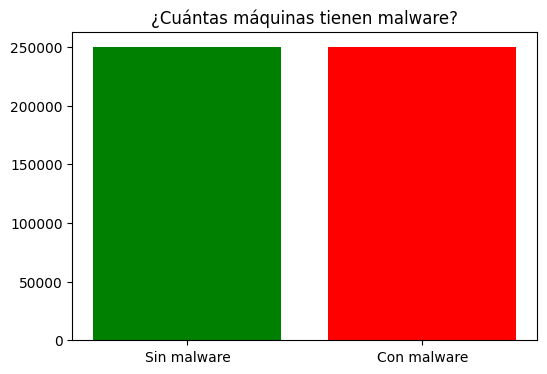

In [39]:
# Gráfico simple
print("📊 GRÁFICO 1: Distribución de malware")
plt.figure(figsize=(6, 4))
plt.bar(['Sin malware', 'Con malware'], conteo.values, color=['green', 'red'])
plt.title('¿Cuántas máquinas tienen malware?')
plt.show()
print()

**1.7 Identificación de outliers**

🔍 IDENTIFICANDO OUTLIERS Y DATOS ERRÓNEOS


/tmp/ipython-input-1774703820.py:18: DtypeWarning: Columns (29,42) have mixed types. Specify dtype option on import or set low_memory=False.
  datos = pd.read_csv("https://www.dropbox.com/s/sxl5bpi2620p496/sample_mmp.csv?dl=1")



📋 SELECCIÓN DE COLUMNAS IMPORTANTES:
----------------------------------------
Se analizarán 15 columnas importantes:
   1. SmartScreen
   2. AVProductStatesIdentifier
   3. AVProductsInstalled
   4. AvSigVersion
   5. EngineVersion
   6. Census_TotalPhysicalRAM
   7. AppVersion
   8. Census_InternalPrimaryDiagonalDisplaySizeInInches
   9. Census_OSInstallTypeName
  10. Wdft_IsGamer
  11. Census_IsAlwaysOnAlwaysConnectedCapable
  12. Census_PrimaryDiskTotalCapacity
  13. Processor
  14. Census_SystemVolumeTotalCapacity
  15. Census_IsWIMBootEnabled

📊 PARTE 1: OUTLIERS EN VARIABLES NUMÉRICAS

🔢 Variables numéricas a analizar (9):
  • AVProductStatesIdentifier
  • AVProductsInstalled
  • Census_TotalPhysicalRAM
  • Census_InternalPrimaryDiagonalDisplaySizeInInches
  • Wdft_IsGamer
  • Census_IsAlwaysOnAlwaysConnectedCapable
  • Census_PrimaryDiskTotalCapacity
  • Census_SystemVolumeTotalCapacity
  • Census_IsWIMBootEnabled

📦 CREANDO BOXPLOTS PARA DETECTAR OUTLIERS VISUALMENTE:

📈 ANALI

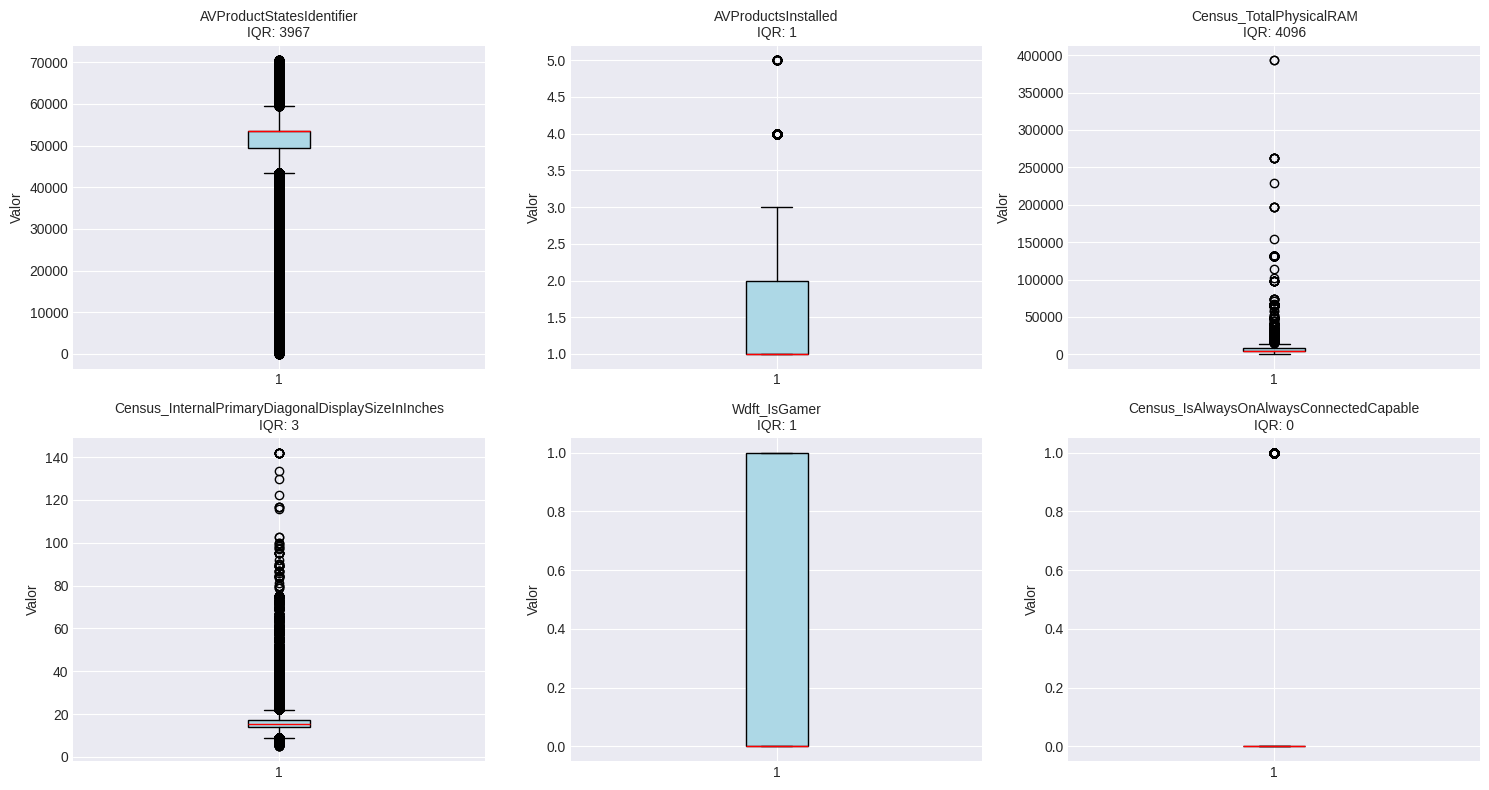


🔤 PARTE 2: DATOS ERRÓNEOS EN VARIABLES CATEGÓRICAS

🔤 Variables categóricas a analizar (6):
  • SmartScreen
  • AvSigVersion
  • EngineVersion
  • AppVersion
  • Census_OSInstallTypeName
  • Processor

📊 GRÁFICOS DE VARIABLES CATEGÓRICAS:

📊 ANALIZANDO: SmartScreen
----------------------------------------
Valores únicos: 12
Valores nulos: 178596 (35.7%)

📈 DISTRIBUCIÓN (Top 5 valores):
  1. 'RequireAdmin': 241594 veces (48.3%)
  2. 'ExistsNotSet': 58497 veces (11.7%)
  3. 'Off': 10388 veces (2.1%)
  4. 'Warn': 7530 veces (1.5%)
  5. 'Prompt': 1950 veces (0.4%)

🔍 CATEGORÍAS RARAS (<1% frecuencia):
  Número de categorías raras: 8
  Ejemplos de categorías raras:
    • 'Prompt' (1950 veces)
    • 'Block' (1274 veces)
    • 'off' (75 veces)

⚠️  VALORES SOSPECHOSOS:
  Encontrados: 1
    • 'ExistsNotSet'

💡 RECOMENDACIÓN:
  Muchas categorías raras - agrupar las menos frecuentes

📊 ANALIZANDO: AvSigVersion
----------------------------------------
Valores únicos: 6455
Valores nulos: 0 (0.0%)

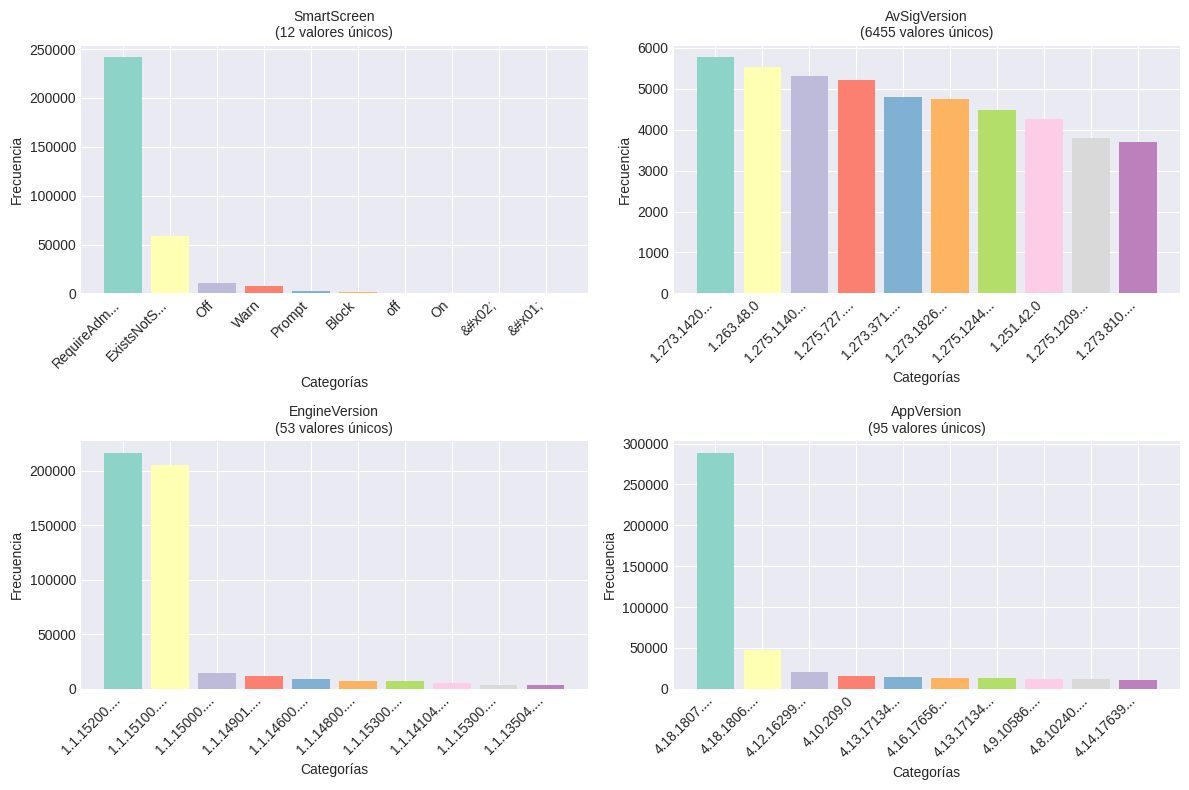

In [77]:
"""
=================================================================
IDENTIFICACIÓN DE OUTLIERS Y DATOS ERRÓNEOS
=================================================================
Estrategia: Analizar solo las columnas más importantes
=================================================================
"""

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("🔍 IDENTIFICANDO OUTLIERS Y DATOS ERRÓNEOS")
print("=" * 60)

# 1. CARGAR DATOS
datos = pd.read_csv("https://www.dropbox.com/s/sxl5bpi2620p496/sample_mmp.csv?dl=1")

# 2. SELECCIONAR COLUMNAS IMPORTANTES (por intuición)
print("\n📋 SELECCIÓN DE COLUMNAS IMPORTANTES:")
print("-" * 40)

# Columnas que SEGURO son importantes para malware
columnas_importantes = [
    'SmartScreen',
    'AVProductStatesIdentifier',
    'AVProductsInstalled',
    'AvSigVersion',
    'EngineVersion',
    'Census_TotalPhysicalRAM',
    'AppVersion',
    'Census_InternalPrimaryDiagonalDisplaySizeInInches',
    'Census_OSInstallTypeName',
    'Wdft_IsGamer',
    'Census_IsAlwaysOnAlwaysConnectedCapable',
    'Census_PrimaryDiskTotalCapacity',
    'Processor',
    'Census_SystemVolumeTotalCapacity',
    'Census_IsWIMBootEnabled'
]

# Filtrar solo las que existen en el dataset
columnas_existentes = [col for col in columnas_importantes if col in datos.columns]
print(f"Se analizarán {len(columnas_existentes)} columnas importantes:")
for i, col in enumerate(columnas_existentes, 1):
    print(f"  {i:2}. {col}")

# ============================================================================
# PARTE 1: OUTLIERS EN VARIABLES NUMÉRICAS (con Boxplots)
# ============================================================================
print("\n" + "=" * 60)
print("📊 PARTE 1: OUTLIERS EN VARIABLES NUMÉRICAS")
print("=" * 60)

# Separar variables numéricas de nuestras importantes
columnas_numericas = []
for col in columnas_existentes:
    if datos[col].dtype in ['int64', 'float64'] and col != 'HasDetections':
        columnas_numericas.append(col)

print(f"\n🔢 Variables numéricas a analizar ({len(columnas_numericas)}):")
for col in columnas_numericas:
    print(f"  • {col}")

# Función para analizar cada variable numérica
def analizar_variable_numerica(df, columna):
    """
    Analiza una variable numérica y detecta outliers
    """
    print(f"\n📈 ANALIZANDO: {columna}")
    print("-" * 40)

    # Estadísticas básicas
    print(f"Tipo: {df[columna].dtype}")
    print(f"Valores únicos: {df[columna].nunique()}")
    print(f"Valores nulos: {df[columna].isnull().sum()} ({df[columna].isnull().sum()/len(df)*100:.1f}%)")

    # Estadísticas descriptivas
    stats = df[columna].describe()
    print(f"\n📊 Estadísticas:")
    print(f"  Mínimo: {stats['min']:.2f}")
    print(f"  Máximo: {stats['max']:.2f}")
    print(f"  Media: {stats['mean']:.2f}")
    print(f"  Mediana: {stats['50%']:.2f}")
    print(f"  Desviación estándar: {stats['std']:.2f}")

    # Detectar outliers con método IQR
    Q1 = stats['25%']
    Q3 = stats['75%']
    IQR = Q3 - Q1

    if IQR > 0:  # Evitar división por cero
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Contar outliers
        outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
        num_outliers = len(outliers)
        porcentaje = (num_outliers / len(df)) * 100

        print(f"\n🔍 OUTLIERS (método IQR):")
        print(f"  Límite inferior: {limite_inferior:.2f}")
        print(f"  Límite superior: {limite_superior:.2f}")
        print(f"  Outliers encontrados: {num_outliers} ({porcentaje:.1f}%)")

        # Verificar valores prohibidos
        if stats['min'] < 0 and columna in ['Census_TotalPhysicalRAM', 'Census_PrimaryDiskTotalCapacity']:
            print(f"\n⚠️  ¡VALORES PROHIBIDOS DETECTADOS!")
            print(f"  {columna} no puede tener valores negativos")
            valores_negativos = df[df[columna] < 0][columna].count()
            print(f"  Valores negativos: {valores_negativos}")

        # Recomendación
        print(f"\n💡 RECOMENDACIÓN:")
        if num_outliers == 0:
            print("  No hay outliers - mantener datos como están")
        elif porcentaje < 5:
            print("  Pocos outliers (<5%) - considerar eliminarlos")
        elif porcentaje < 15:
            print("  Algunos outliers (5-15%) - revisar si son errores")
        else:
            print("  Muchos outliers (>15%) - probablemente distribución natural")

    return Q1, Q3, IQR

# Crear boxplots para cada variable numérica
print("\n📦 CREANDO BOXPLOTS PARA DETECTAR OUTLIERS VISUALMENTE:")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(columnas_numericas[:6]):  # Mostrar solo primeras 6
    # Boxplot
    bp = axes[idx].boxplot(datos[col].dropna(), patch_artist=True, vert=True)

    # Colorear
    bp['boxes'][0].set_facecolor('lightblue')
    bp['medians'][0].set_color('red')

    # Calcular outliers
    Q1 = datos[col].quantile(0.25)
    Q3 = datos[col].quantile(0.75)
    IQR = Q3 - Q1

    # Añadir información
    axes[idx].set_title(f'{col}\nIQR: {IQR:.0f}', fontsize=10)
    axes[idx].set_ylabel('Valor')

    # Analizar estadísticas
    analizar_variable_numerica(datos, col)

# Ocultar ejes vacíos si hay menos de 6 columnas
for idx in range(len(columnas_numericas[:6]), 6):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================================
# PARTE 2: DATOS ERRÓNEOS EN VARIABLES CATEGÓRICAS
# ============================================================================
print("\n" + "=" * 60)
print("🔤 PARTE 2: DATOS ERRÓNEOS EN VARIABLES CATEGÓRICAS")
print("=" * 60)

# Separar variables categóricas de nuestras importantes
columnas_categoricas = []
for col in columnas_existentes:
    if datos[col].dtype == 'object':
        columnas_categoricas.append(col)

print(f"\n🔤 Variables categóricas a analizar ({len(columnas_categoricas)}):")
for col in columnas_categoricas:
    print(f"  • {col}")

def analizar_variable_categorica(df, columna):
    """
    Analiza una variable categórica y detecta problemas
    """
    print(f"\n📊 ANALIZANDO: {columna}")
    print("-" * 40)

    # Estadísticas básicas
    valores_unicos = df[columna].nunique()
    print(f"Valores únicos: {valores_unicos}")
    print(f"Valores nulos: {df[columna].isnull().sum()} ({df[columna].isnull().sum()/len(df)*100:.1f}%)")

    # Distribución de valores
    conteo = df[columna].value_counts()

    print(f"\n📈 DISTRIBUCIÓN (Top 5 valores):")
    for i, (valor, frecuencia) in enumerate(conteo.head(5).items(), 1):
        porcentaje = (frecuencia / len(df)) * 100
        print(f"  {i}. '{valor}': {frecuencia} veces ({porcentaje:.1f}%)")

    # Detectar categorías raras (<1% de frecuencia)
    categorias_raras = conteo[conteo / len(df) < 0.01]
    num_categorias_raras = len(categorias_raras)

    print(f"\n🔍 CATEGORÍAS RARAS (<1% frecuencia):")
    print(f"  Número de categorías raras: {num_categorias_raras}")

    if num_categorias_raras > 0:
        print("  Ejemplos de categorías raras:")
        for valor, frecuencia in categorias_raras.head(3).items():
            print(f"    • '{valor}' ({frecuencia} veces)")

    # Detectar valores sospechosos
    valores_sospechosos = []
    if df[columna].dtype == 'object':
        for valor in df[columna].dropna().unique():
            if isinstance(valor, str):
                valor_str = str(valor).lower()
                if ('unknown' in valor_str or
                    'null' in valor_str or
                    'nan' in valor_str or
                    'none' in valor_str or
                    'not' in valor_str):
                    valores_sospechosos.append(valor)

    print(f"\n⚠️  VALORES SOSPECHOSOS:")
    if valores_sospechosos:
        print(f"  Encontrados: {len(valores_sospechosos)}")
        for valor in valores_sospechosos[:3]:  # Mostrar solo 3
            print(f"    • '{valor}'")
    else:
        print("  No se encontraron valores sospechosos evidentes")

    # Recomendación
    print(f"\n💡 RECOMENDACIÓN:")
    if valores_unicos > 20:
        print("  Demasiados valores únicos - considerar agrupar en 'Otros'")
    elif num_categorias_raras > 5:
        print("  Muchas categorías raras - agrupar las menos frecuentes")
    else:
        print("  Distribución aceptable - mantener como está")

# Crear gráficos para variables categóricas
print("\n📊 GRÁFICOS DE VARIABLES CATEGÓRICAS:")
num_categoricas = min(4, len(columnas_categoricas))  # Máximo 4 gráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, col in enumerate(columnas_categoricas[:num_categoricas]):
    # Tomar top 10 categorías para no saturar gráfico
    top_categorias = datos[col].value_counts().head(10)

    # Gráfico de barras
    bars = axes[idx].bar(range(len(top_categorias)), top_categorias.values,
                        color=plt.cm.Set3(range(len(top_categorias))))

    # Configurar
    axes[idx].set_title(f'{col}\n({datos[col].nunique()} valores únicos)', fontsize=10)
    axes[idx].set_xlabel('Categorías')
    axes[idx].set_ylabel('Frecuencia')

    # Rotar etiquetas
    axes[idx].set_xticks(range(len(top_categorias)))
    axes[idx].set_xticklabels([str(x)[:10] + '...' if len(str(x)) > 10 else str(x)
                              for x in top_categorias.index], rotation=45, ha='right')

    # Analizar la variable
    analizar_variable_categorica(datos, col)

# Ocultar ejes vacíos
for idx in range(num_categoricas, 4):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()




In [79]:
datos.AvSigVersion.value_counts()

,count
AvSigVersion,
1.273.1420.0,5771
1.263.48.0,5537
1.275.1140.0,5317
1.275.727.0,5214
1.273.371.0,4799
...,...
1.243.647.0,1
1.229.387.0,1
1.239.1469.0,1


In [80]:
# Identificar valores con menos de 300 ocurrencias
conteos = datos['AvSigVersion'].value_counts()
valores_a_reemplazar = conteos[conteos < 100].index.tolist()

# Reemplazar esos valores por 'Otros'
datos['AvSigVersion'] = datos['AvSigVersion'].replace(valores_a_reemplazar, 'Otros')

In [81]:
datos.AvSigVersion.value_counts()

,count
AvSigVersion,
Otros,48497
1.273.1420.0,5771
1.263.48.0,5537
1.275.1140.0,5317
1.275.727.0,5214
...,...
1.273.205.0,103
1.267.15.0,103
1.269.1192.0,102


In [82]:
datos.AppVersion.value_counts()

,count
AppVersion,
4.18.1807.18075,288809
4.18.1806.18062,47641
4.12.16299.15,20197
4.10.209.0,15292
4.13.17134.1,14414
...,...
4.13.17639.1000,1
4.15.17650.1001,1
4.13.17618.1000,1


In [83]:
# Identificar valores con menos de 4500 ocurrencias
conteos = datos['AppVersion'].value_counts()
valores_a_reemplazar = conteos[conteos < 4500].index.tolist()

# Reemplazar esos valores por 'Otros'
datos['AppVersion'] = datos['AppVersion'].replace(valores_a_reemplazar, 'Otros')

In [84]:
datos.AppVersion.value_counts()

,count
AppVersion,
4.18.1807.18075,288809
4.18.1806.18062,47641
Otros,36463
4.12.16299.15,20197
4.10.209.0,15292
4.13.17134.1,14414
4.16.17656.18052,13185
4.13.17134.228,12729
4.9.10586.1106,11432


In [85]:
datos.SmartScreen.value_counts()

,count
SmartScreen,
RequireAdmin,241594
ExistsNotSet,58497
Off,10388
Warn,7530
Prompt,1950
Block,1274
off,75
On,53
&#x02;,20


In [86]:
datos.SmartScreen= datos.SmartScreen.str.lower()

In [87]:
## Eliminar datos "raros de SmartCreen"
datos = datos[(datos['SmartScreen'] != '&#x02;') & (datos['SmartScreen'] != '&#x01;')]

In [88]:
datos.SmartScreen.value_counts()

,count
SmartScreen,
requireadmin,241595
existsnotset,58497
off,10463
warn,7530
prompt,1950
block,1274
on,61


In [89]:
datos['Census_OSVersion'].value_counts()

,count
Census_OSVersion,
10.0.17134.228,79970
10.0.17134.165,50508
10.0.16299.431,30518
10.0.17134.285,26289
10.0.17134.112,19500
...,...
10.0.14328.1000,1
10.0.14926.1000,1
10.0.17618.1000,1


In [90]:
datos.Census_InternalPrimaryDiagonalDisplaySizeInInches.describe()

,Census_InternalPrimaryDiagonalDisplaySizeInInches
count,497312.000000
mean,16.689828
std,5.932115
min,4.900000
25%,13.900000
50%,15.500000
75%,17.200000
max,142.000000


In [91]:
# Identificar valores con menos de 1000 ocurrencias
conteos = datos['Census_OSVersion'].value_counts()
valores_a_reemplazar = conteos[conteos < 1000].index.tolist()

# Reemplazar esos valores por 'Otros'
datos['Census_OSVersion'] = datos['Census_OSVersion'].replace(valores_a_reemplazar, 'Otros')

In [92]:
datos['Census_OSVersion'].value_counts()

,count
Census_OSVersion,
10.0.17134.228,79970
10.0.17134.165,50508
Otros,34185
10.0.16299.431,30518
10.0.17134.285,26289
...,...
10.0.10586.218,1116
10.0.15063.250,1082
10.0.10586.1106,1061


In [93]:
datos.OsVer.value_counts()

,count
OsVer,
10.0.0.0,483796
6.3.0.0,10818
6.1.1.0,5281
6.1.0.0,33
10.0.3.0,12
10.0.1.0,7
10.0.32.72,2
6.3.1.0,2
10.0.0.1,2


In [94]:
# Identificar valores con menos de 100 ocurrencias
conteos = datos['OsVer'].value_counts()
valores_a_reemplazar = conteos[conteos < 100].index.tolist()

# Reemplazar esos valores por 'Otros'
datos['OsVer'] = datos['OsVer'].replace(valores_a_reemplazar, 'Otros')

In [95]:
datos.OsVer.value_counts()

,count
OsVer,
10.0.0.0,483796
6.3.0.0,10818
6.1.1.0,5281
Otros,71


**1.8 Identificación de datos erróneos**


ANÁLISIS ESPECÍFICO - COLUMNAS DE MALWARE

🔍 TIPO: VERSIONES
----------------------------------------
📊 AvSigVersion:
   • Nulos: 0 (0.0%)
   • Únicos: 905
   • Formato versión OK: 90.3%
📊 EngineVersion:
   • Nulos: 0 (0.0%)
   • Únicos: 53
   • Formato versión OK: 100.0%
📊 AppVersion:
   • Nulos: 0 (0.0%)
   • Únicos: 14
   • Formato versión OK: 92.7%

🔍 TIPO: ANTIVIRUS
----------------------------------------
📊 AVProductStatesIdentifier:
   • Nulos: 1938 (0.4%)
   • Únicos: 5516
📊 AVProductsInstalled:
   • Nulos: 1938 (0.4%)
   • Únicos: 5
📊 SmartScreen:
   • Nulos: 178596 (35.7%)
   • Únicos: 7

🔍 TIPO: HARDWARE
----------------------------------------
📊 Census_TotalPhysicalRAM:
   • Nulos: 4554 (0.9%)
   • Únicos: 552
   • ⚠️ Valores bajos de RAM detectados
📊 Census_PrimaryDiskTotalCapacity:
   • Nulos: 2974 (0.6%)
   • Únicos: 1103
📊 Census_SystemVolumeTotalCapacity:
   • Nulos: 2974 (0.6%)
   • Únicos: 142048
📊 Processor:
   • Nulos: 0 (0.0%)
   • Únicos: 3
📊 Census_InternalPrim

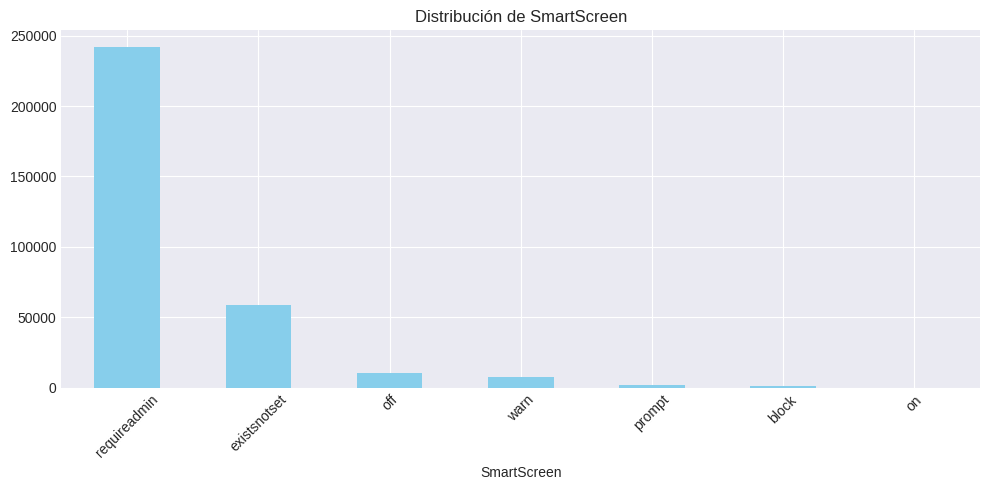

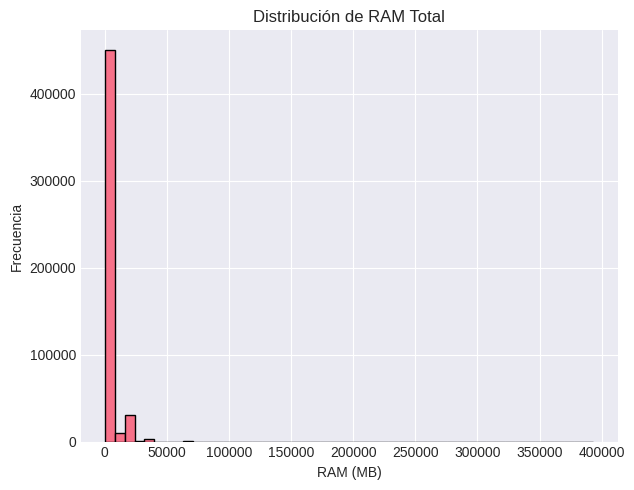

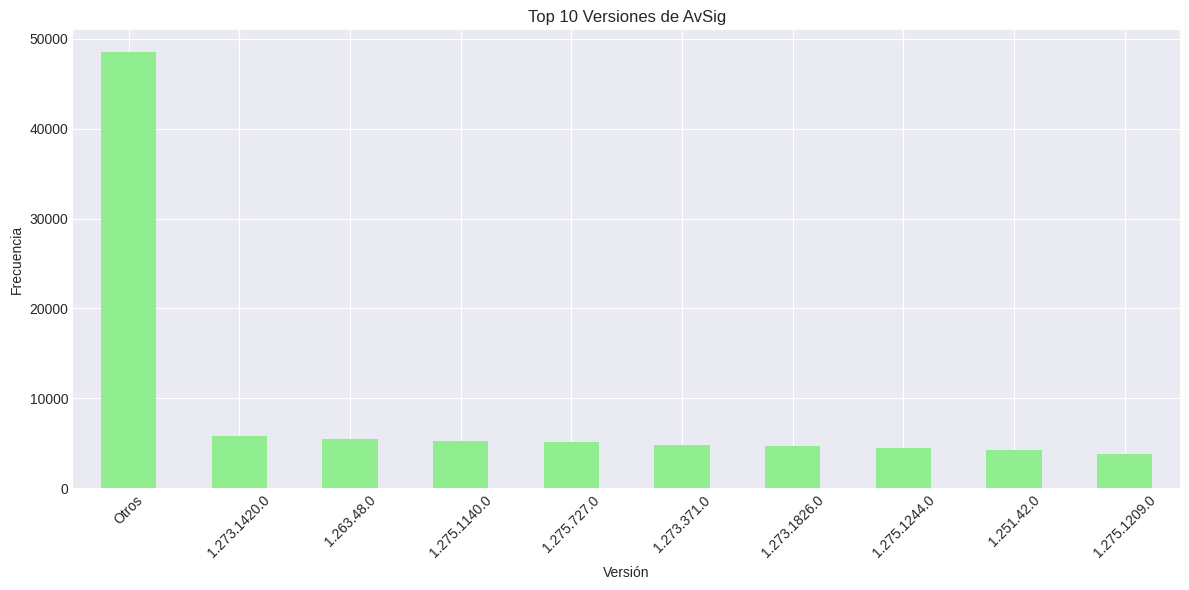


RECOMENDACIONES DE PREPROCESAMIENTO
⚠️  IMPUTAR 'SmartScreen': 35.7% nulos
❌ ELIMINAR 'Census_IsWIMBootEnabled': 63.5% nulos (demasiados)

CREANDO DATASET LIMPIO PARA MODELO
✅ Dataset limpio creado: (499966, 8)
   Columnas: ['SmartScreen', 'AVProductStatesIdentifier', 'AvSigVersion', 'Census_TotalPhysicalRAM', 'Census_OSInstallTypeName', 'Wdft_IsGamer', 'Processor', 'SmartScreen_encoded']


In [97]:
# ===========================================
# 2. ANÁLISIS ESPECÍFICO POR TIPO DE COLUMNA
# ===========================================
print("\n" + "=" * 80)
print("ANÁLISIS ESPECÍFICO - COLUMNAS DE MALWARE")
print("=" * 80)

# Grupo las columnas por tipo para análisis específico
columnas_por_tipo = {
    'VERSIONES': ['AvSigVersion', 'EngineVersion', 'AppVersion'],
    'ANTIVIRUS': ['AVProductStatesIdentifier', 'AVProductsInstalled', 'SmartScreen'],
    'HARDWARE': ['Census_TotalPhysicalRAM', 'Census_PrimaryDiskTotalCapacity',
                 'Census_SystemVolumeTotalCapacity', 'Processor',
                 'Census_InternalPrimaryDiagonalDisplaySizeInInches'],
    'SISTEMA_OPERATIVO': ['Census_OSInstallTypeName', 'Census_IsWIMBootEnabled'],
    'USO': ['Wdft_IsGamer', 'Census_IsAlwaysOnAlwaysConnectedCapable']
}

# ===========================================
# 3. FUNCIÓN DE ANÁLISIS ESPECÍFICO
# ===========================================
def analizar_columna_malware(datos, columna, tipo):
    """Análisis específico para columnas de malware"""

    resultados = {
        'columna': columna,
        'tipo_general': tipo,
        'existe': columna in datos.columns
    }

    if not resultados['existe']:
        return resultados

    # Datos básicos
    resultados['dtype'] = str(datos[columna].dtype)
    resultados['nulos'] = datos[columna].isnull().sum()
    resultados['pct_nulos'] = (resultados['nulos'] / len(datos)) * 100
    resultados['unicos'] = datos[columna].nunique()

    # Análisis específico por tipo
    if tipo == 'VERSIONES':
        # Para columnas de versión
        valores = datos[columna].astype(str)
        resultados['formato_correcto'] = valores.str.contains(r'\d+\.\d+', na=False).mean() * 100
        resultados['versiones_top'] = valores.value_counts().head(3).to_dict()

    elif tipo == 'ANTIVIRUS':
        # Para SmartScreen específicamente
        if columna == 'SmartScreen':
            valores_validos = ['ExistsNotSet', 'Enabled', 'Disabled']
            valores = datos[columna].astype(str)
            resultados['valores_validos_pct'] = valores.isin(valores_validos).mean() * 100

        # Para AVProductStatesIdentifier (debería ser numérico)
        elif 'AVProduct' in columna:
            if pd.api.types.is_numeric_dtype(datos[columna]):
                resultados['valores_negativos'] = (datos[columna] < 0).sum()
                resultados['valores_cero'] = (datos[columna] == 0).sum()

    elif tipo == 'HARDWARE':
        # Análisis de hardware
        if pd.api.types.is_numeric_dtype(datos[columna]):
            resultados['min'] = datos[columna].min()
            resultados['max'] = datos[columna].max()
            resultados['media'] = datos[columna].mean()

            # Verificar valores imposibles
            if 'RAM' in columna and resultados['min'] < 1024:  # Menos de 1GB
                resultados['nota'] = '⚠️ Valores bajos de RAM detectados'
            if 'Disk' in columna and resultados['min'] < 10240:  # Menos de 10GB
                resultados['nota'] = '⚠️ Valores bajos de disco detectados'

    elif tipo == 'SISTEMA_OPERATIVO':
        # Para Census_OSInstallTypeName
        if columna == 'Census_OSInstallTypeName':
            resultados['distribucion'] = datos[columna].value_counts(normalize=True).head(5).to_dict()

    elif tipo == 'USO':
        # Columnas booleanas/categóricas
        if datos[columna].nunique() <= 5:
            resultados['distribucion'] = datos[columna].value_counts(normalize=True).to_dict()

    return resultados

# ===========================================
# 4. EJECUTAR ANÁLISIS
# ===========================================
resultados_detallados = []

for tipo, columnas in columnas_por_tipo.items():
    print(f"\n🔍 TIPO: {tipo}")
    print("-" * 40)

    for col in columnas:
        resultado = analizar_columna_malware(datos, col, tipo)
        resultados_detallados.append(resultado)

        if not resultado['existe']:
            print(f"❌ {col}: NO EXISTE")
            continue

        print(f"📊 {col}:")
        print(f"   • Nulos: {resultado['nulos']} ({resultado['pct_nulos']:.1f}%)")
        print(f"   • Únicos: {resultado['unicos']}")

        # Mostrar información específica
        if 'formato_correcto' in resultado:
            print(f"   • Formato versión OK: {resultado['formato_correcto']:.1f}%")

        if 'distribucion' in resultado:
            print(f"   • Distribución: {resultado['distribucion']}")

        if 'nota' in resultado:
            print(f"   • {resultado['nota']}")

# ===========================================
# 5. VISUALIZACIONES ESPECÍFICAS (CORREGIDO)
# ===========================================
print("\n" + "=" * 80)
print("VISUALIZACIONES ESPECÍFICAS")
print("=" * 80)

# 5.1 Distribución de SmartScreen (CORREGIDO: datos en lugar de datos_sin_malware)
if 'SmartScreen' in datos.columns:
    plt.figure(figsize=(10, 5))
    datos['SmartScreen'].value_counts().plot(kind='bar', color='skyblue')
    plt.title('Distribución de SmartScreen')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 5.2 Distribución de RAM (histograma)
if 'Census_TotalPhysicalRAM' in datos.columns:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    datos['Census_TotalPhysicalRAM'].hist(bins=50, edgecolor='black')
    plt.title('Distribución de RAM Total')
    plt.xlabel('RAM (MB)')
    plt.ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()

# 5.3 Versiones más comunes
if 'AvSigVersion' in datos.columns:
    plt.figure(figsize=(12, 6))
    top_versions = datos['AvSigVersion'].value_counts().head(10)
    top_versions.plot(kind='bar', color='lightgreen')
    plt.title('Top 10 Versiones de AvSig')
    plt.xlabel('Versión')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ===========================================
# 6. RECOMENDACIONES DE LIMPIEZA
# ===========================================
print("\n" + "=" * 80)
print("RECOMENDACIONES DE PREPROCESAMIENTO")
print("=" * 80)

recomendaciones = []

for resultado in resultados_detallados:
    if not resultado['existe']:
        continue

    col = resultado['columna']
    pct_nulos = resultado['pct_nulos']

    # Recomendaciones basadas en % de nulos
    if pct_nulos > 40:
        recomendaciones.append(f"❌ ELIMINAR '{col}': {pct_nulos:.1f}% nulos (demasiados)")
    elif pct_nulos > 10:
        recomendaciones.append(f"⚠️  IMPUTAR '{col}': {pct_nulos:.1f}% nulos")

    # Recomendaciones específicas
    if resultado['tipo_general'] == 'VERSIONES' and 'formato_correcto' in resultado:
        if resultado['formato_correcto'] < 90:
            recomendaciones.append(f"🔧 LIMPIAR formato '{col}': solo {resultado['formato_correcto']:.1f}% con formato correcto")

    if resultado['tipo_general'] == 'HARDWARE' and 'min' in resultado:
        if 'RAM' in col and resultado['min'] < 512:  # Menos de 0.5GB
            recomendaciones.append(f"📝 REVISAR '{col}': valor mínimo muy bajo ({resultado['min']} MB)")
        if 'Disk' in col and resultado['min'] < 5120:  # Menos de 5GB
            recomendaciones.append(f"📝 REVISAR '{col}': disco mínimo muy bajo ({resultado['min']} MB)")

# Mostrar recomendaciones
if recomendaciones:
    for rec in recomendaciones:
        print(rec)
else:
    print("✅ No se necesitan limpiezas críticas")

# ===========================================
# 7. CREAR DATASET LIMPIO PARA MODELO
# ===========================================
print("\n" + "=" * 80)
print("CREANDO DATASET LIMPIO PARA MODELO")
print("=" * 80)

# Lista final de columnas a mantener (ajusta según análisis)
columnas_modelo = [
    'SmartScreen',
    'AVProductStatesIdentifier',
    'AvSigVersion',
    'Census_TotalPhysicalRAM',
    'Census_OSInstallTypeName',
    'Wdft_IsGamer',
    'Processor'
]

# Filtrar solo las que existen
columnas_modelo = [col for col in columnas_modelo if col in datos.columns]

if columnas_modelo:
    df_limpio = datos[columnas_modelo].copy()

    # Transformaciones básicas recomendadas
    if 'SmartScreen' in df_limpio.columns:
        # Codificar SmartScreen
        df_limpio['SmartScreen_encoded'] = df_limpio['SmartScreen'].map({
            'ExistsNotSet': 0,
            'Enabled': 1,
            'Disabled': 2
        })


    print(f"✅ Dataset limpio creado: {df_limpio.shape}")
    print(f"   Columnas: {list(df_limpio.columns)}")

    # Guardar si quieres
    # df_limpio.to_csv('datos_limpios_malware.csv', index=False)
    # print("💾 Guardado como 'datos_limpios_malware.csv'")
else:
    print("❌ No hay columnas válidas para el modelo")

**1.9. Correlación de variables con el target**




In [99]:
"""
=================================================================
1.9 CORRELACIÓN DE VARIABLES CON EL TARGET (HasDetections)
=================================================================
Objetivo: Encontrar qué variables están más relacionadas con tener malware
=================================================================
"""

print("🔗 1.9 CORRELACIÓN DE VARIABLES CON EL TARGET")
print("=" * 60)


# ============================================================================
# PARTE 1.9: CORRELACIÓN PARA VARIABLES NUMÉRICAS
# ============================================================================
print("\n📊 PARTE 1.9: CORRELACIÓN NUMÉRICA CON HASDETECTIONS")
print("-" * 50)

# 1. Encontrar columnas numéricas
columnas_numericas = datos.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Quitar el target de la lista para no correlacionarlo consigo mismo
if 'HasDetections' in columnas_numericas:
    columnas_numericas.remove('HasDetections')

print(f"Analizando {len(columnas_numericas)} columnas numéricas")
print("(Esto puede tardar un momento...)")

# 2. Calcular correlación de CADA columna numérica con el target
print("\n🔢 CALCULANDO CORRELACIONES...")

correlaciones = {}
for col in columnas_numericas[:30]:  # Solo primeras 30 para no saturar
    # Correlación de Pearson (mide relación lineal)
    correlacion = datos[col].corr(datos['HasDetections'])
    correlaciones[col] = correlacion

# 3. Ordenar de mayor a menor correlación (valor absoluto)
print("\n🏆 TOP 15 VARIABLES CON MAYOR CORRELACIÓN:")
print("(Ordenadas por importancia, sin importar si es + o -)")
print("-" * 60)

# Crear DataFrame con correlaciones
df_correlaciones = pd.DataFrame({
    'Variable': list(correlaciones.keys()),
    'Correlación': list(correlaciones.values()),
    'Corr_Abs': [abs(c) for c in correlaciones.values()]  # Valor absoluto
})

# Ordenar por valor absoluto (más importante)
df_correlaciones = df_correlaciones.sort_values('Corr_Abs', ascending=False)

# Mostrar top 15
for i, (_, fila) in enumerate(df_correlaciones.head(15).iterrows(), 1):
    signo = "+" if fila['Correlación'] > 0 else "-"
    print(f"{i:2}. {fila['Variable']:<35}: {signo}{abs(fila['Correlación']):.4f}")

# 4. Interpretación simple
print("\n💡 ¿QUÉ SIGNIFICA LA CORRELACIÓN?")
print("• +0.10: Aumenta variable → Aumenta probabilidad de malware")
print("• -0.10: Aumenta variable → Disminuye probabilidad de malware")
print("• Cerca de 0: Poca relación con malware")

🔗 1.9 CORRELACIÓN DE VARIABLES CON EL TARGET

📊 PARTE 1.9: CORRELACIÓN NUMÉRICA CON HASDETECTIONS
--------------------------------------------------
Analizando 53 columnas numéricas
(Esto puede tardar un momento...)

🔢 CALCULANDO CORRELACIONES...

🏆 TOP 15 VARIABLES CON MAYOR CORRELACIÓN:
(Ordenadas por importancia, sin importar si es + o -)
------------------------------------------------------------
 1. AVProductsInstalled                : -0.1488
 2. AVProductStatesIdentifier          : +0.1162
 3. IsProtected                        : +0.0562
 4. Census_ProcessorCoreCount          : +0.0561
 5. Census_PrimaryDiskTotalCapacity    : +0.0481
 6. AVProductsEnabled                  : -0.0420
 7. RtpStateBitfield                   : +0.0403
 8. IsSxsPassiveMode                   : -0.0340
 9. OsBuild                            : +0.0244
10. Census_ProcessorModelIdentifier    : +0.0217
11. Census_HasOpticalDiskDrive         : +0.0201
12. OsSuite                            : -0.0199
13. IeV

**10. Correlación de las variables con la clase (unidimensional)**

In [ ]:
corr=datos.corr(numeric_only=True)
corr
corr.style.background_gradient(cmap='coolwarm')

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Unnamed: 0,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,AVProductStatesIdentifier,AVProductsInstalled,AVProductsEnabled,HasTpm,CountryIdentifier,CityIdentifier,OrganizationIdentifier,GeoNameIdentifier,LocaleEnglishNameIdentifier,OsBuild,OsSuite,IsProtected,AutoSampleOptIn,SMode,IeVerIdentifier,Firewall,UacLuaenable,Census_OEMNameIdentifier,Census_OEMModelIdentifier,Census_ProcessorCoreCount,Census_ProcessorManufacturerIdentifier,Census_ProcessorModelIdentifier,Census_PrimaryDiskTotalCapacity,Census_SystemVolumeTotalCapacity,Census_HasOpticalDiskDrive,Census_TotalPhysicalRAM,Census_InternalPrimaryDiagonalDisplaySizeInInches,Census_InternalPrimaryDisplayResolutionHorizontal,Census_InternalPrimaryDisplayResolutionVertical,Census_InternalBatteryNumberOfCharges,Census_OSBuildNumber,Census_OSBuildRevision,Census_OSInstallLanguageIdentifier,Census_OSUILocaleIdentifier,Census_IsPortableOperatingSystem,Census_IsFlightingInternal,Census_IsFlightsDisabled,Census_ThresholdOptIn,Census_FirmwareManufacturerIdentifier,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
Unnamed: 0,1.000000,-0.000357,0.000262,-0.000004,0.016144,-0.001192,0.000289,0.000415,-0.000288,-0.000472,0.000191,0.000771,-0.000186,-0.000975,-0.000417,0.000488,-0.000916,-0.001984,0.000127,-0.001150,0.001094,0.002452,0.000283,0.000495,-0.000001,0.000528,-0.001200,-0.001347,-0.000726,0.000198,0.000719,-0.000687,0.000730,0.000889,-0.000820,-0.001000,0.001809,-0.000434,-0.000098,0.001888,0.001588,-0.000072,0.000476,-0.000306,-0.001211,-0.000138,nan,-0.001281,0.001000,0.000216,0.003110,-0.001062,-0.001515,-0.000161
IsBeta,-0.000357,1.000000,0.000213,-0.000187,nan,-0.002033,-0.000885,-0.000176,-0.012734,0.000941,0.000753,nan,0.000353,0.000804,-0.005251,0.001101,0.000339,-0.000007,-0.000031,0.006900,nan,-0.000002,-0.000014,0.000209,-0.001365,0.000518,0.001510,-0.001055,-0.000628,-0.000409,-0.000582,nan,nan,nan,-0.000856,-0.003793,-0.000389,-0.000919,-0.000925,-0.000032,nan,nan,-0.000038,0.000628,-0.001194,-0.001374,nan,-0.000119,-0.000536,-0.000280,-0.000350,-0.000906,0.002248,-0.001414
RtpStateBitfield,0.000262,0.000213,1.000000,-0.885639,-0.004962,0.105237,-0.183095,0.009346,-0.007860,0.011350,-0.001190,0.004990,0.018069,0.006882,-0.027464,-0.011023,0.060631,-0.012158,0.002226,-0.023449,0.006215,0.000213,0.003448,0.000081,-0.018380,0.003625,-0.005396,-0.026347,-0.019181,-0.010053,-0.023076,-0.012444,-0.016916,-0.010796,-0.005590,-0.033989,0.024159,-0.014009,-0.013738,-0.000159,0.000735,0.000570,-0.002449,0.009963,0.005886,-0.016266,nan,0.008394,0.009711,0.006366,0.020115,-0.024648,-0.001504,0.040304
IsSxsPassiveMode,-0.000004,-0.000187,-0.885639,1.000000,0.012028,-0.110956,0.194294,0.027948,0.013870,-0.011686,0.000591,-0.004700,-0.018672,-0.012320,0.045279,0.016242,-0.033295,-0.000701,-0.002769,-0.004239,-0.000927,-0.000187,-0.004793,0.000010,0.023228,0.000769,0.008502,0.021589,0.016353,0.010481,0.026987,0.009528,0.022267,0.015532,0.001066,0.043867,-0.023590,0.011113,0.010585,-0.001009,-0.000611,-0.000504,0.000790,-0.010323,-0.007070,0.020660,nan,-0.010625,-0.005630,-0.003095,-0.015879,0.031757,0.001163,-0.034038
DefaultBrowsersIdentifier,0.016144,nan,-0.004962,0.012028,1.000000,0.004171,-0.002898,-0.003407,-0.013139,-0.001054,0.002879,0.005629,-0.020074,0.035982,-0.044086,0.057070,0.019045,0.002627,nan,-0.057355,0.014369,0.005758,-0.030262,-0.022665,0.001428,-0.012479,-0.010970,0.038187,0.058940,-0.024088,0.014567,-0.023323,0.008975,0.002951,-0.054322,-0.048266,-0.020446,0.003371,0.002013,-0.001326,nan,nan,nan,0.010240,0.029571,0.069342,nan,-0.018352,0.011398,0.005897,-0.000176,0.010875,0.019271,0.000956
AVProductStatesIdentifier,-0.001192,-0.002033,0.105237,-0.110956,0.004171,1.000000,-0.631974,-0.124388,0.141697,0.006808,-0.004896,0.010980,0.019346,-0.080393,0.002206,-0

In [100]:
# Analizando la correlación que tiene la variable HasDetections con AVProductStatesIdentifier con un 0,1161;
# y la variable AVProductsInstalled con un -0,1487; podríamos contemplar que son las variables que más
# correlación tienen con HasDetections.

# En este caso, a más productos antivirus, menos malware (para el caso de AVProductsInstalled).
# Por otro lado, ciertas configuraciones antivirus tienen más riesgo (para el caso AVProductStatesIdentifier).

# La variable IsProtected con un 0.0562 de correlación nos dice que si el antivirus hizo un chequeo por última vez, tenemos más probabilidades de tener malware.
# La variable Census_ProcessorCoreCount con un 0.0561 nos dice que si tenemos más números de procesadores en el ordenador, tenemos más probabilidades de tener malware.
# La variable Census_PrimaryDiskTotalCapacity con un 0.0480 nos dice que si tenemos más espacio en el disco primario en MB, tendremos más probabilidades de tener malware.




🎯 PARTE 10: ANÁLISIS POR CLASE (0=Sin malware, 1=Con malware)

📈 COMPARANDO VARIABLES PARA MÁQUINAS CON Y SIN MALWARE
--------------------------------------------------

Analizando las 5 variables más importantes:
  • AVProductsInstalled
  • AVProductStatesIdentifier
  • IsProtected
  • Census_ProcessorCoreCount
  • Census_PrimaryDiskTotalCapacity


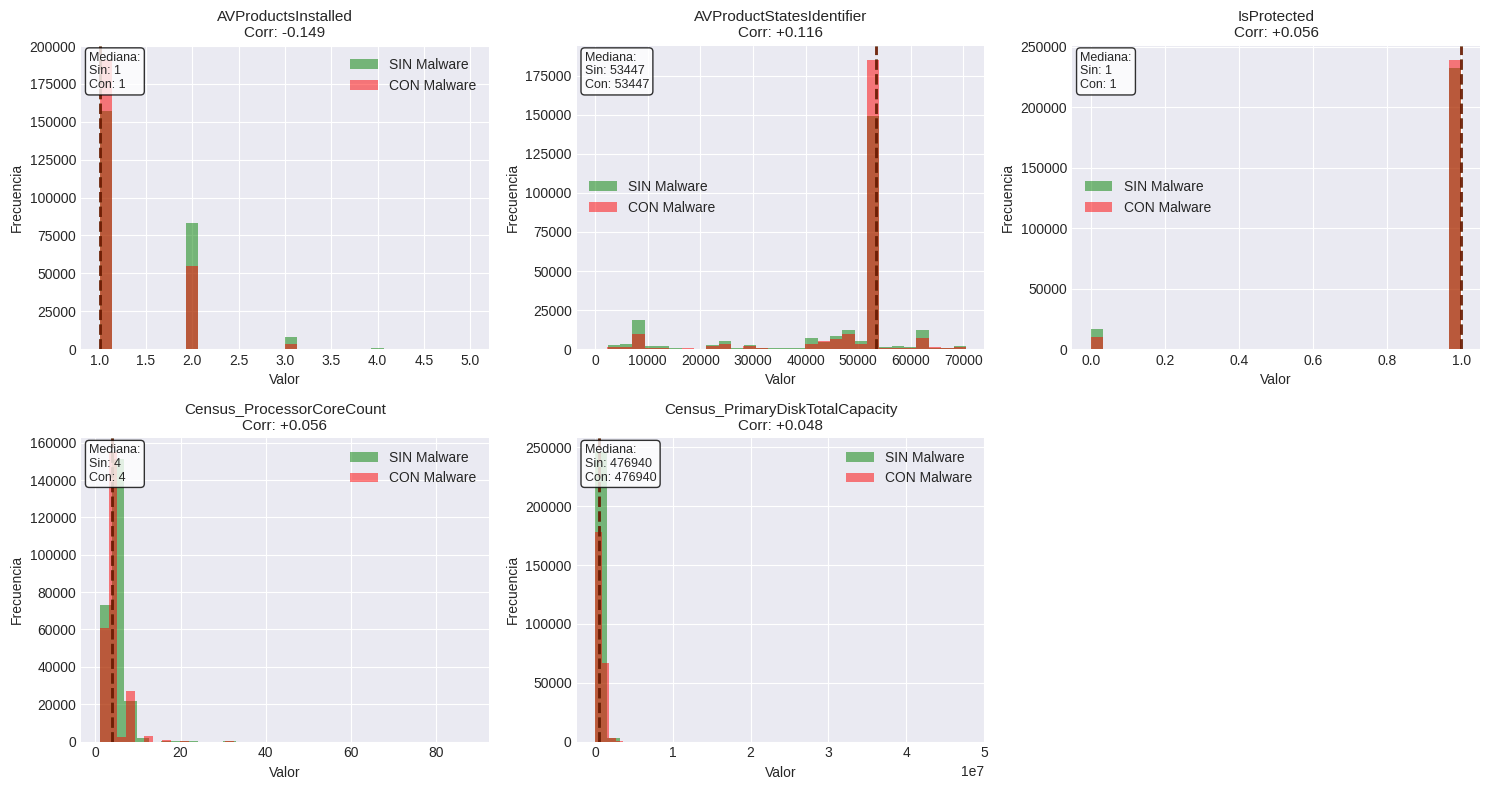


🔤 CORRELACIÓN CON VARIABLES CATEGÓRICAS IMPORTANTES

📊 TASA DE MALWARE POR CATEGORÍA (variables clave):
--------------------------------------------------

📍 VARIABLE: IsProtected
   Valores únicos: 2
   Tasa de malware por categoría (Top 2):
     • '1.0': 50.7% malware (471,039 máquinas)
     • '0.0': 38.3% malware (27,001 máquinas)

📍 VARIABLE: Firewall
   Valores únicos: 2
   Tasa de malware por categoría (Top 2):
     • '1.0': 50.0% malware (484,038 máquinas)
     • '0.0': 49.3% malware (10,766 máquinas)

📍 VARIABLE: Census_OSVersion
   Valores únicos: 67
   Tasa de malware por categoría (Top 5):
     • '10.0.17134.228': 53.4% malware (79,970 máquinas)
     • '10.0.17134.165': 56.2% malware (50,508 máquinas)
     • 'Otros': 46.3% malware (34,185 máquinas)
     • '10.0.16299.431': 49.8% malware (30,518 máquinas)
     • '10.0.17134.285': 50.5% malware (26,289 máquinas)

📋 RESUMEN DE CORRELACIONES ENCONTRADAS

🎯 VARIABLES MÁS RELACIONADAS CON MALWARE:

🔴 AUMENTAN RIESGO (correlación 

In [101]:
# ============================================================================
# PARTE 10: CORRELACIÓN UNIDIMENSIONAL CON LA CLASE
# ============================================================================
print("\n\n" + "=" * 60)
print("🎯 PARTE 10: ANÁLISIS POR CLASE (0=Sin malware, 1=Con malware)")
print("=" * 60)

print("\n📈 COMPARANDO VARIABLES PARA MÁQUINAS CON Y SIN MALWARE")
print("-" * 50)

# Seleccionar 5 variables numéricas importantes de la parte anterior
top_5_variables = df_correlaciones.head(5)['Variable'].tolist()

print(f"\nAnalizando las 5 variables más importantes:")
for var in top_5_variables:
    print(f"  • {var}")

# Crear gráficos de comparación
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(top_5_variables[:6]):
    ax = axes[idx]

    # Separar datos por clase
    datos_sin_malware = datos[datos['HasDetections'] == 0][col].dropna()
    datos_con_malware = datos[datos['HasDetections'] == 1][col].dropna()

    # Crear histogramas superpuestos
    ax.hist(datos_sin_malware, bins=30, alpha=0.5, label='SIN Malware', color='green')
    ax.hist(datos_con_malware, bins=30, alpha=0.5, label='CON Malware', color='red')

    ax.set_title(f'{col}\nCorr: {correlaciones[col]:+.3f}', fontsize=11)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend()

    # Añadir líneas de mediana
    mediana_sin = datos_sin_malware.median()
    mediana_con = datos_con_malware.median()

    ax.axvline(mediana_sin, color='darkgreen', linestyle='--', alpha=0.7, linewidth=2)
    ax.axvline(mediana_con, color='darkred', linestyle='--', alpha=0.7, linewidth=2)

    # Texto informativo
    info_text = f"Mediana:\nSin: {mediana_sin:.0f}\nCon: {mediana_con:.0f}"
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Ocultar eje extra si hay menos de 6 variables
for idx in range(len(top_5_variables[:6]), 6):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================================
# ANÁLISIS DE VARIABLES CATEGÓRICAS IMPORTANTES
# ============================================================================
print("\n" + "=" * 60)
print("🔤 CORRELACIÓN CON VARIABLES CATEGÓRICAS IMPORTANTES")
print("=" * 60)

print("\n📊 TASA DE MALWARE POR CATEGORÍA (variables clave):")
print("-" * 50)

# Seleccionar algunas variables categóricas importantes
variables_categoricas = ['IsProtected', 'Firewall', 'Census_OSVersion']

for col in variables_categoricas:
    if col in datos.columns:
        print(f"\n📍 VARIABLE: {col}")
        print(f"   Valores únicos: {datos[col].nunique()}")

        # Calcular tasa de malware para cada categoría (top 5)
        valores_top = datos[col].value_counts().head(5).index

        print(f"   Tasa de malware por categoría (Top {len(valores_top)}):")
        for categoria in valores_top:
            # Filtrar datos para esta categoría
            subset = datos[datos[col] == categoria]
            if len(subset) > 0:
                tasa_malware = subset['HasDetections'].mean() * 100
                conteo = len(subset)
                print(f"     • '{categoria}': {tasa_malware:.1f}% malware ({conteo:,} máquinas)")

# ============================================================================
# RESUMEN Y CONCLUSIONES
# ============================================================================
print("\n" + "=" * 60)
print("📋 RESUMEN DE CORRELACIONES ENCONTRADAS")
print("=" * 60)

print("\n🎯 VARIABLES MÁS RELACIONADAS CON MALWARE:")

# Variables con correlación positiva (aumentan riesgo)
print("\n🔴 AUMENTAN RIESGO (correlación positiva):")
variables_positivas = df_correlaciones[df_correlaciones['Correlación'] > 0].head(3)
for _, fila in variables_positivas.iterrows():
    print(f"  • {fila['Variable']}: +{fila['Correlación']:.4f}")
    print(f"    (A mayor valor → más probabilidad de malware)")

# Variables con correlación negativa (disminuyen riesgo)
print("\n🟢 DISMINUYEN RIESGO (correlación negativa):")
variables_negativas = df_correlaciones[df_correlaciones['Correlación'] < 0].head(3)
for _, fila in variables_negativas.iterrows():
    print(f"  • {fila['Variable']}: {fila['Correlación']:.4f}")
    print(f"    (A mayor valor → menos probabilidad de malware)")

print("\n💡 INTERPRETACIÓN PARA WINDOWS DEFENDER:")
print("1. Variables con correlación positiva:")
print("   • Podrían indicar configuraciones vulnerables")
print("   • Ejemplo: Si 'AVProductStatesIdentifier' alto = más riesgo")
print("   → Acción: Recomendar cambiar configuración")

print("\n2. Variables con correlación negativa:")
print("   • Podrían indicar factores protectores")
print("   • Ejemplo: Si 'AVProductsInstalled' alto = menos riesgo")
print("   → Acción: Promover buenas prácticas")

print("\n3. Variables categóricas importantes:")
print("   • 'IsProtected' y 'Firewall' deberían tener baja tasa de malware")
print("   → Verificar si la protección realmente funciona")

print("\n" + "=" * 60)
print("✅ ANÁLISIS DE CORRELACIÓN COMPLETADO")
print("=" * 60)

**11. Visualización gráfica de las distribuciones**

✓ Numéricas: histogramas, box-plots, violin-plots, vista por deciles, etc.

✓ Categóricas: bar-charts, conteo directo, etc.

In [102]:
"""
=================================================================
11. VISUALIZACIÓN GRÁFICA DE LAS DISTRIBUCIONES
=================================================================
Objetivo: Mostrar cómo se distribuyen los datos de forma visual
=================================================================
"""



print("📊 11. VISUALIZACIÓN GRÁFICA DE LAS DISTRIBUCIONES")
print("=" * 60)



# 2. Bucle de visualización
for col in datos.columns:
    # Saltamos identificadores y el target
    if col in ['MachineIdentifier', 'HasDetections', 'Unnamed: 0', 'n_nulos']:
        continue

    # Get actual list of categorical and numerical column names
    categoricas_cols = datos.select_dtypes(include=['object']).columns.tolist() # exlude dos variables o tres que hemos cambiado con los cambios efectuados
    numericas_cols = datos.select_dtypes(include=['int64', 'float64']).columns.tolist()

    plt.figure(figsize=(12, 5))

    if col in categoricas_cols:
        # Para categóricas: Top 15 valores más frecuentes para no saturar el eje X
        top_values = datos[col].value_counts().nlargest(15).index
        df_plot = datos[datos[col].isin(top_values)]

        sns.countplot(data=df_plot, x=col, hue='HasDetections', palette='viridis')
        plt.title(f"Top 15 categorías en '{col}' vs HasDetections")
        plt.xticks(rotation=45)

    elif col in numericas_cols:
        # Para numéricas: Un histograma con KDE es más útil que un scatter contra un target binario
        sns.histplot(data=datos, x=col, hue='HasDetections', kde=False, bins=30, element="step")
        plt.title(f"Distribución de '{col}' por estado de infección")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [103]:
columnas_numericas = datos.select_dtypes(include=['int64', 'float64']).columns.tolist()  # LISTA
columnas_categoricas = datos.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()  # LISTA


for col in datos.columns:
    # Saltamos identificadores y el target
    if col in ['MachineIdentifier', 'HasDetections', 'Unnamed: 0', 'n_nulos']:
        continue

    if col in columnas_categoricas:
        print(f'Distintos valores en {col}')
        display(datos[col].value_counts())

    elif col in columnas_numericas:
        print(f'Rango de valores en {col}')
        display(datos[col].describe())

# %%
for col in datos.columns:
    # Saltamos identificadores y el target
    if col in ['MachineIdentifier', 'HasDetections', 'Unnamed: 0', 'n_nulos']:
        continue

    plt.figure(figsize=(12, 5))

    if col in columnas_categoricas:
        # Para categóricas: Top 15 valores más frecuentes para no saturar el eje X
        top_values = datos[col].value_counts().nlargest(15).index
        df_plot = datos[datos[col].isin(top_values)]

        sns.countplot(data=df_plot, x=col, hue='HasDetections', palette='viridis')
        plt.title(f"Top 15 categorías en '{col}' vs HasDetections")
        plt.xticks(rotation=45)

    elif col in columnas_numericas:
        sns.boxplot(data=datos, x='HasDetections', y=col, palette='viridis')
        plt.title(f"Distribución de '{col}' por estado de infección")

    plt.tight_layout()
    plt.show()

# %%
for col in datos.columns:
    # Saltamos identificadores y el target
    if col in ['MachineIdentifier', 'HasDetections', 'Unnamed: 0', 'n_nulos']:
        continue

    plt.figure(figsize=(12, 5))

    if col in columnas_categoricas:
        # Para categóricas: Top 15 valores más frecuentes para no saturar el eje X
        top_values = datos[col].value_counts().nlargest(15).index
        df_plot = datos[datos[col].isin(top_values)]

        sns.countplot(data=df_plot, x=col, hue='HasDetections', palette='viridis')
        plt.title(f"Top 15 categorías en '{col}' vs HasDetections")
        plt.xticks(rotation=45)

    elif col in columnas_numericas:
        # Para numéricas: Un histograma con KDE es más útil que un scatter contra un target binario
        sns.histplot(data=datos, x=col, hue='HasDetections', kde=False, bins=30, element="step")
        plt.title(f"Distribución de '{col}' por estado de infección")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# **1.2 Análisis Multi-variante de los datos**

**1. Distribución de variables 2 a 2 (scatter-plots)**


🔗 PASO 12: RELACIONES ENTRE VARIABLES...
1. Scatter plots de variables con mayor correlación con el target:
   Variables encontradas: 15 de 15


/tmp/ipython-input-603577071.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=labels)
/tmp/ipython-input-603577071.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=labels)
/tmp/ipython-input-603577071.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=labels)
/tmp/ipython-input-603577071.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be

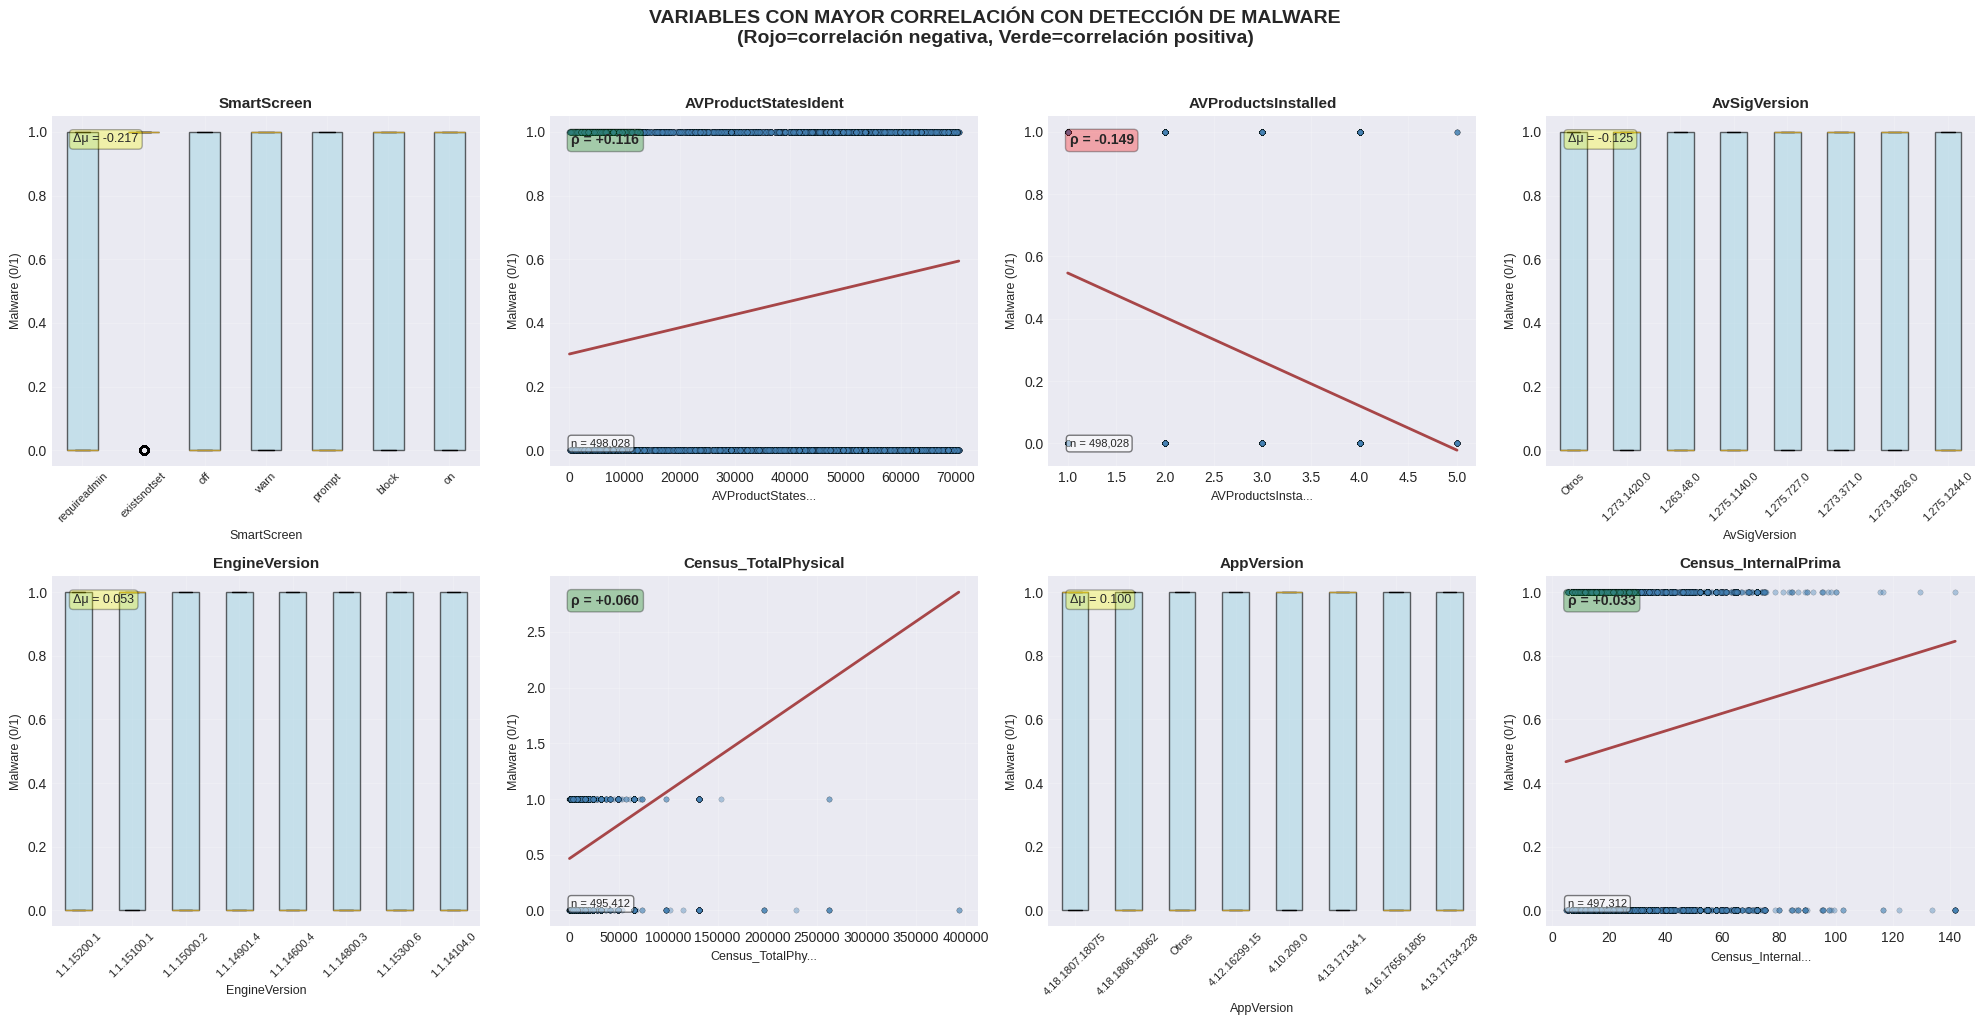


2. Matriz de correlación entre variables importantes:


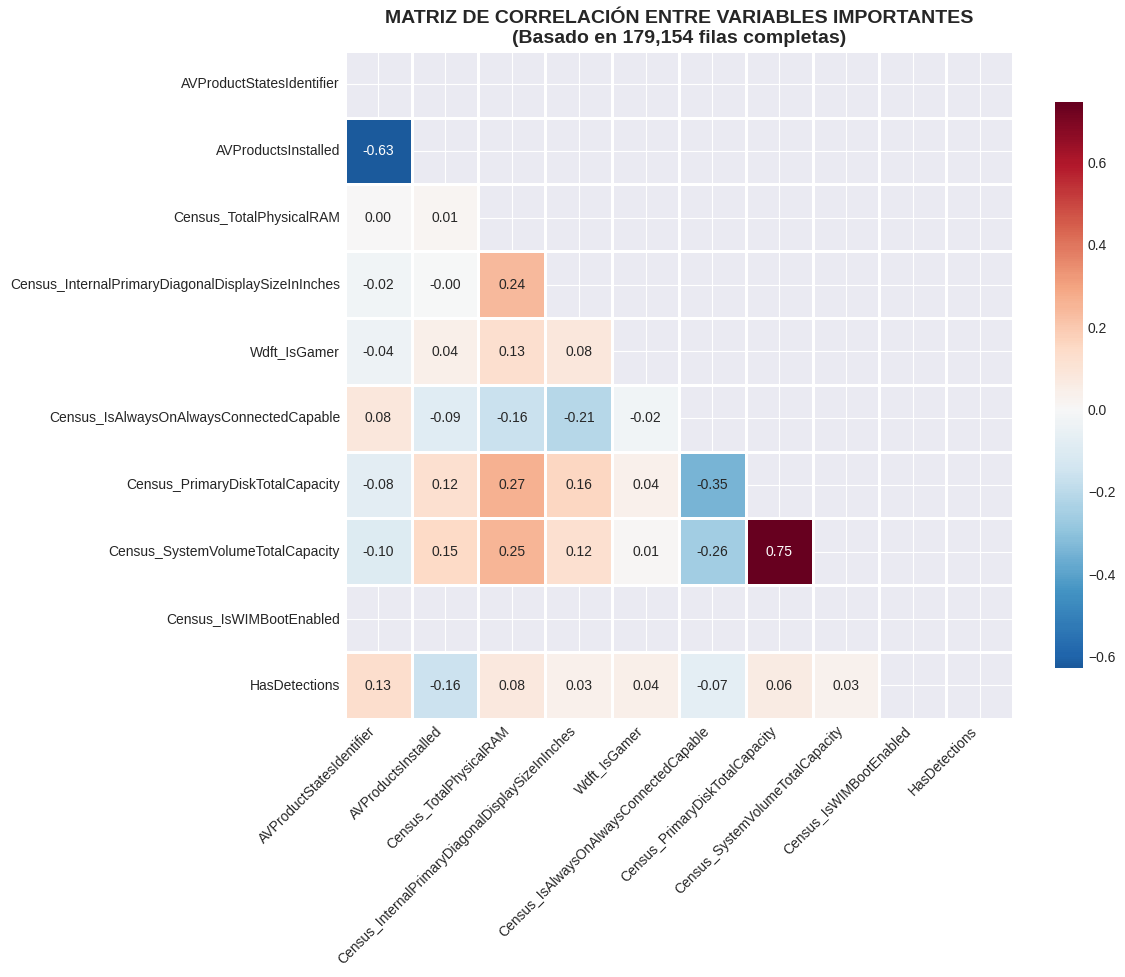


3. Resumen de correlaciones con HasDetections (n=179,154):
   AVProductsInstalled                 :   -0.1561
   AVProductStatesIdentifier           :   +0.1295
   Census_TotalPhysicalRAM             :   +0.0787
   Census_IsAlwaysOnAlwaysConnectedCapable :   -0.0706
   Census_PrimaryDiskTotalCapacity     :   +0.0640
   Wdft_IsGamer                        :   +0.0436
   Census_InternalPrimaryDiagonalDisplaySizeInInches :   +0.0337
   Census_SystemVolumeTotalCapacity    :   +0.0278
   Census_IsWIMBootEnabled             :   -nan


In [104]:
# -----------------------------------------------------------------
# PASO 12: RELACIONES ENTRE VARIABLES
# -----------------------------------------------------------------
print("\n🔗 PASO 12: RELACIONES ENTRE VARIABLES...")

print("1. Scatter plots de variables con mayor correlación con el target:")

# Variables con mayor correlación (de tu lista)
variables_correlacion = [
    'SmartScreen',
    'AVProductStatesIdentifier',
    'AVProductsInstalled',
    'AvSigVersion',
    'EngineVersion',
    'Census_TotalPhysicalRAM',
    'AppVersion',
    'Census_InternalPrimaryDiagonalDisplaySizeInInches',
    'Census_OSInstallTypeName',
    'Wdft_IsGamer',
    'Census_IsAlwaysOnAlwaysConnectedCapable',
    'Census_PrimaryDiskTotalCapacity',
    'Processor',
    'Census_SystemVolumeTotalCapacity',
    'Census_IsWIMBootEnabled'
]

# Filtrar solo las que existen en los datos
variables_existentes = [v for v in variables_correlacion if v in datos.columns]
print(f"   Variables encontradas: {len(variables_existentes)} de {len(variables_correlacion)}")

if len(variables_existentes) >= 4:
    # Crear figura con 2x4 = 8 subplots (una por variable)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for idx, variable in enumerate(variables_existentes[:8]):  # Máximo 8 gráficos
        if idx < len(axes):
            ax = axes[idx]

            # Obtener coeficiente de correlación real
            if datos[variable].dtype in ['int64', 'float64']:
                # Filtrar filas donde ambas variables no sean NaN
                mask = datos[[variable, 'HasDetections']].notna().all(axis=1)
                x_data = datos.loc[mask, variable]
                y_data = datos.loc[mask, 'HasDetections']

                corr_valor = x_data.corr(y_data)
                color = 'red' if corr_valor < 0 else 'green'
                signo = '-' if corr_valor < 0 else '+'

                # Scatter plot para variables numéricas
                ax.scatter(x_data, y_data,
                          alpha=0.4, s=15, color='steelblue', edgecolor='black', linewidth=0.2)

                # Añadir línea de tendencia (solo si hay datos suficientes)
                if len(x_data) > 1:
                    try:
                        z = np.polyfit(x_data, y_data, 1)
                        p = np.poly1d(z)
                        sorted_idx = np.argsort(x_data)
                        ax.plot(x_data.iloc[sorted_idx],
                               p(x_data.iloc[sorted_idx]),
                               color='darkred', linewidth=2, alpha=0.7)
                    except:
                        pass  # Si falla el polyfit, continuar sin línea de tendencia

                # Etiqueta con correlación
                ax.text(0.05, 0.95, f'ρ = {signo}{abs(corr_valor):.3f}',
                       transform=ax.transAxes, fontsize=10, fontweight='bold',
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))

                # Añadir conteo de datos
                ax.text(0.05, 0.05, f'n = {len(x_data):,}',
                       transform=ax.transAxes, fontsize=8,
                       verticalalignment='bottom',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

            else:
                # Para variables categóricas, hacer boxplot
                # Tomar top 8 categorías para mejor visualización
                top_cats = datos[variable].dropna().value_counts().nlargest(8).index
                datos_filtrados = datos[datos[variable].isin(top_cats)]

                # Crear boxplot manualmente para mejor control
                data_to_plot = []
                labels = []
                for cat in top_cats:
                    subset = datos_filtrados[datos_filtrados[variable] == cat]['HasDetections']
                    if len(subset) > 0:
                        data_to_plot.append(subset.dropna().values)
                        labels.append(str(cat)[:15])  # Truncar etiquetas largas

                if data_to_plot:  # Solo si hay datos
                    bp = ax.boxplot(data_to_plot, patch_artist=True, labels=labels)

                    # Colorear las cajas
                    for patch in bp['boxes']:
                        patch.set_facecolor('lightblue')
                        patch.set_alpha(0.6)

                    ax.tick_params(axis='x', rotation=45, labelsize=8)

                    # Calcular diferencia de medias entre categorías
                    if len(data_to_plot) >= 2:
                        mean_diff = np.mean(data_to_plot[0]) - np.mean(data_to_plot[-1])
                        ax.text(0.05, 0.95, f'Δμ = {mean_diff:.3f}',
                               transform=ax.transAxes, fontsize=9,
                               verticalalignment='top',
                               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
                else:
                    ax.text(0.5, 0.5, 'Sin datos suficientes',
                           transform=ax.transAxes, ha='center', va='center')

            ax.set_title(f'{variable[:20]}', fontsize=11, fontweight='bold')
            ax.set_xlabel(variable[:15] + '...' if len(variable) > 15 else variable, fontsize=9)
            ax.set_ylabel('Malware (0/1)', fontsize=9)
            ax.grid(True, alpha=0.2)

    # Ajustar layout
    plt.suptitle('VARIABLES CON MAYOR CORRELACIÓN CON DETECCIÓN DE MALWARE\n' +
                '(Rojo=correlación negativa, Verde=correlación positiva)',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # 2. Heatmap de correlaciones entre estas variables
    print("\n2. Matriz de correlación entre variables importantes:")

    # Filtrar solo variables numéricas
    vars_numericas = [v for v in variables_existentes if datos[v].dtype in ['int64', 'float64']]
    vars_numericas.append('HasDetections')  # Añadir el target

    if len(vars_numericas) > 2:
        # Filtrar filas completas (sin NaN en ninguna de las variables)
        datos_completos = datos[vars_numericas].dropna()
        if len(datos_completos) > 0:
            corr_matrix = datos_completos.corr()

            plt.figure(figsize=(12, 10))
            mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Máscara para triángulo superior
            heatmap = sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r',
                                 center=0, fmt='.2f', linewidths=1,
                                 square=True, cbar_kws={"shrink": 0.8})

            plt.title('MATRIZ DE CORRELACIÓN ENTRE VARIABLES IMPORTANTES\n' +
                     f'(Basado en {len(datos_completos):,} filas completas)',
                     fontsize=14, fontweight='bold')
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

            # Mostrar correlaciones más fuertes con el target
            print(f"\n3. Resumen de correlaciones con HasDetections (n={len(datos_completos):,}):")
            target_corrs = corr_matrix['HasDetections'].drop('HasDetections').sort_values(key=abs, ascending=False)
            for var, corr in target_corrs.head(10).items():
                signo = '  +' if corr > 0 else '  -'
                print(f"   {var:35} : {signo}{abs(corr):.4f}")
        else:
            print("   No hay suficientes filas completas para calcular correlaciones")

**2. Correlación de las variables 2 a 2 (correlación lineal)**


2. Matriz de correlación (variables numéricas):
✅ Variables encontradas: 16/16
📊 Numéricas para correlación: 10
📊 Categóricas (no en correlación): 6
   (Categóricas excluidas: ['SmartScreen', 'AvSigVersion', 'EngineVersion', 'AppVersion', 'Census_OSInstallTypeName', 'Processor'])


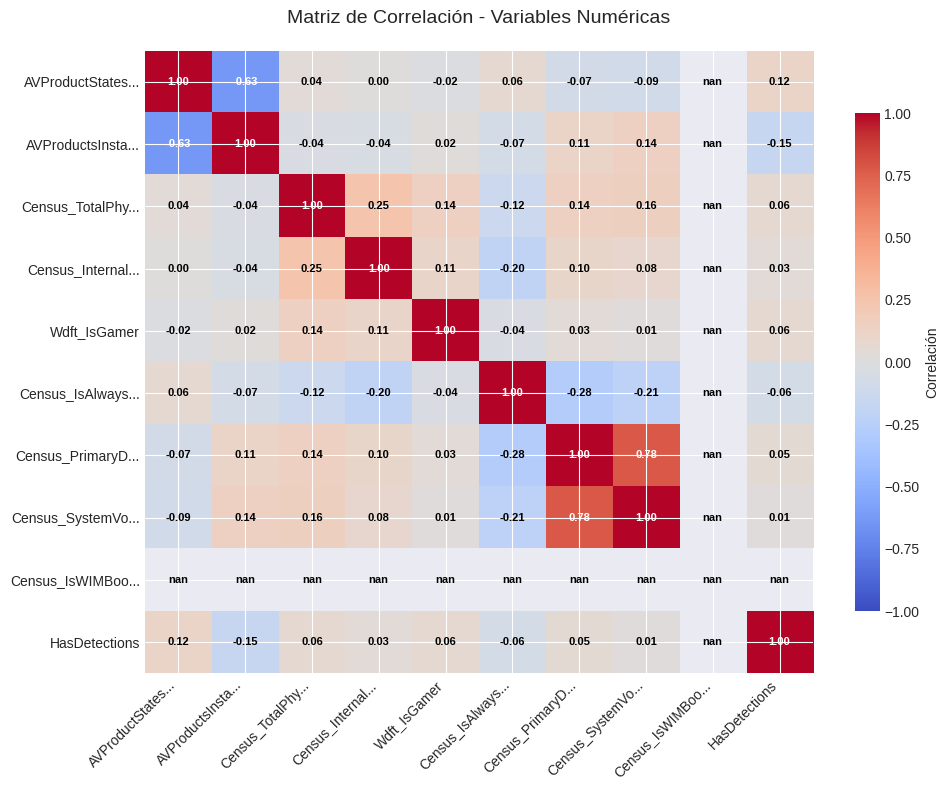


📈 CORRELACIONES CON HasDetections (variable objetivo):
   Correlación absoluta | Variable
   ----------------------------------------
   0.149 (-) | AVProductsInstalled
   0.116 (+) | AVProductStatesIdentifier
   0.063 (-) | Census_IsAlwaysOnAlwaysConnectedCapable
   0.060 (+) | Census_TotalPhysicalRAM
   0.057 (+) | Wdft_IsGamer
   0.048 (+) | Census_PrimaryDiskTotalCapacity
   0.033 (+) | Census_InternalPrimaryDiagonalDisplaySizeInInches
   0.014 (+) | Census_SystemVolumeTotalCapacity
   nan (-) | Census_IsWIMBootEnabled


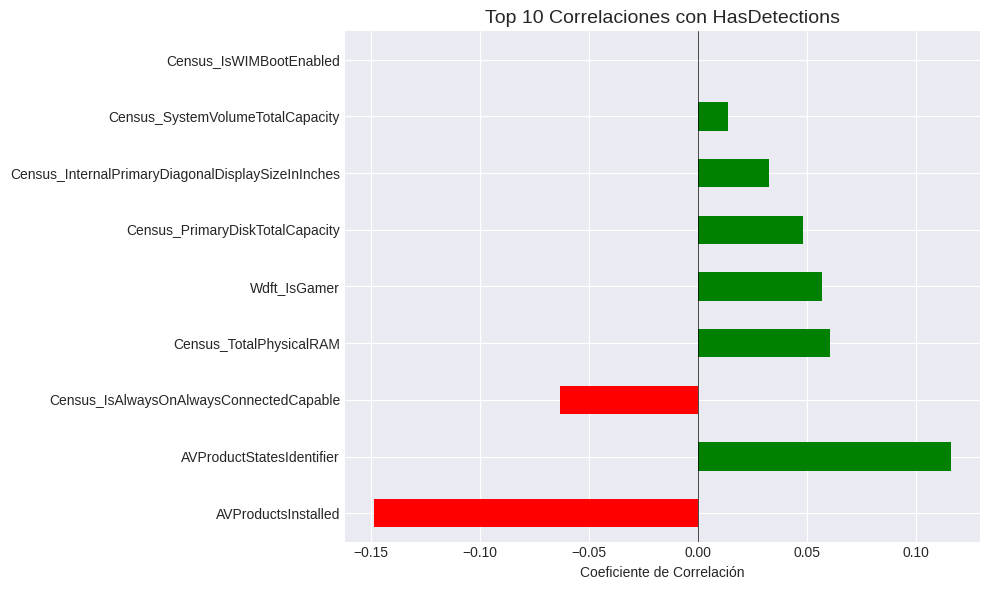

In [105]:
print("\n2. Matriz de correlación (variables numéricas):")

# Lista de variables que QUIERES analizar
variables_interes = [
    'SmartScreen',
    'AVProductStatesIdentifier',
    'AVProductsInstalled',
    'AvSigVersion',
    'EngineVersion',
    'Census_TotalPhysicalRAM',
    'AppVersion',
    'Census_InternalPrimaryDiagonalDisplaySizeInInches',
    'Census_OSInstallTypeName',
    'Wdft_IsGamer',
    'Census_IsAlwaysOnAlwaysConnectedCapable',
    'Census_PrimaryDiskTotalCapacity',
    'Processor',
    'Census_SystemVolumeTotalCapacity',
    'Census_IsWIMBootEnabled',
    'HasDetections'
]

# 1. Filtrar solo las que existen en los datos
variables_existentes = [v for v in variables_interes if v in datos.columns]
print(f"✅ Variables encontradas: {len(variables_existentes)}/{len(variables_interes)}")

# 2. Separar en numéricas y categóricas
variables_numericas = []
variables_categoricas = []

for col in variables_existentes:
    if pd.api.types.is_numeric_dtype(datos[col]):
        variables_numericas.append(col)
    else:
        variables_categoricas.append(col)

print(f"📊 Numéricas para correlación: {len(variables_numericas)}")
print(f"📊 Categóricas (no en correlación): {len(variables_categoricas)}")

if variables_categoricas:
    print(f"   (Categóricas excluidas: {variables_categoricas})")

# 3. Matriz de correlación SOLO con numéricas
if variables_numericas:
    datos_corr = datos[variables_numericas].corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(datos_corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(label='Correlación', shrink=0.8)

    # Etiquetas más legibles
    plt.xticks(range(len(variables_numericas)),
               [v[:15] + '...' if len(v) > 15 else v for v in variables_numericas],
               rotation=45, ha='right')
    plt.yticks(range(len(variables_numericas)),
               [v[:15] + '...' if len(v) > 15 else v for v in variables_numericas])

    plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, pad=20)

    # Añadir valores de correlación
    for i in range(len(variables_numericas)):
        for j in range(len(variables_numericas)):
            valor = datos_corr.iloc[i, j]
            color = 'white' if abs(valor) > 0.5 else 'black'
            tamaño = 8 if len(variables_numericas) <= 10 else 6
            plt.text(j, i, f'{valor:.2f}', ha='center', va='center',
                    color=color, fontsize=tamaño, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 4. Mostrar correlaciones más fuertes con HasDetections (si existe)
    if 'HasDetections' in variables_numericas:
        print("\n📈 CORRELACIONES CON HasDetections (variable objetivo):")
        correlaciones = datos_corr['HasDetections'].sort_values(key=abs, ascending=False)

        # Excluir la correlación consigo mismo (1.0)
        correlaciones = correlaciones[correlaciones.index != 'HasDetections']

        print("   Correlación absoluta | Variable")
        print("   " + "-" * 40)
        for var, corr in correlaciones.head(10).items():
            signo = "+" if corr > 0 else "-"
            print(f"   {abs(corr):.3f} ({signo}) | {var}")

        # Gráfico de correlaciones principales
        plt.figure(figsize=(10, 6))
        correlaciones.head(10).plot(kind='barh', color=['red' if x < 0 else 'green' for x in correlaciones.head(10)])
        plt.title('Top 10 Correlaciones con HasDetections', fontsize=14)
        plt.xlabel('Coeficiente de Correlación')
        plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        plt.tight_layout()
        plt.show()
else:
    print("⚠️  No hay variables numéricas para calcular correlación")

In [106]:
# AVProductStatesIdentifier y AVProductsInstalled presentan una correlación de 0.63.
# Por un lado, AVProductsInstalled es el número de antivirus instalados (0,1,2,3...)
# Por otro lado, AVProductStatesIdentifier es la configuración específica del antivirus.
# La correlación nos dice que: a medida que aumenta el ID de configuración del antivirus, también aumenta el número de antivirus instalados.
# O viceversa: a más antivirus instalados, es más probable tener ciertas configuraciones.


In [107]:
# Census_ProcessorCoreCount y Census_TotalPysicalRAM presentan una correlación de 0.61.
# Por un lado, Censes_ProcessorCoreCount es el número de núcleos del CPU.
# Por otro lado, Census_TotalPysicalRAM es la cantidad de memoria de RAM (en MB).
# La correlación nos dice que: a medida que tenemos ordenadores con procesadores más potentes (más núcleos), también tienen más memoria RAM.
# Esto tiene sentido: el hardware de gama alta suele venir con componentes balanceados.


**3. Cross-tabs**


📋 PASO 13: TABLAS CRUZADAS...
1. Tablas cruzadas de variables categóricas importantes:
   Variables categóricas: 11
   Variables numéricas: 10

2. Tablas cruzadas con HasDetections:

   1. SmartScreen:
               Conteo                 Porcentaje       
HasDetections       0       1     All          0      1
SmartScreen                                            
block             634     640    1274      49.8%  50.2%
existsnotset    11382   47115   58497      19.5%  80.5%
off              5365    5098   10463      51.3%  48.7%
on                 21      40      61      34.4%  65.6%
prompt           1022     928    1950      52.4%  47.6%
requireadmin   135705  105890  241595      56.2%  43.8%
warn             3224    4306    7530      42.8%  57.2%
      Chi-cuadrado: 25552.58, p-valor: 0.0000


<Figure size 1000x500 with 0 Axes>

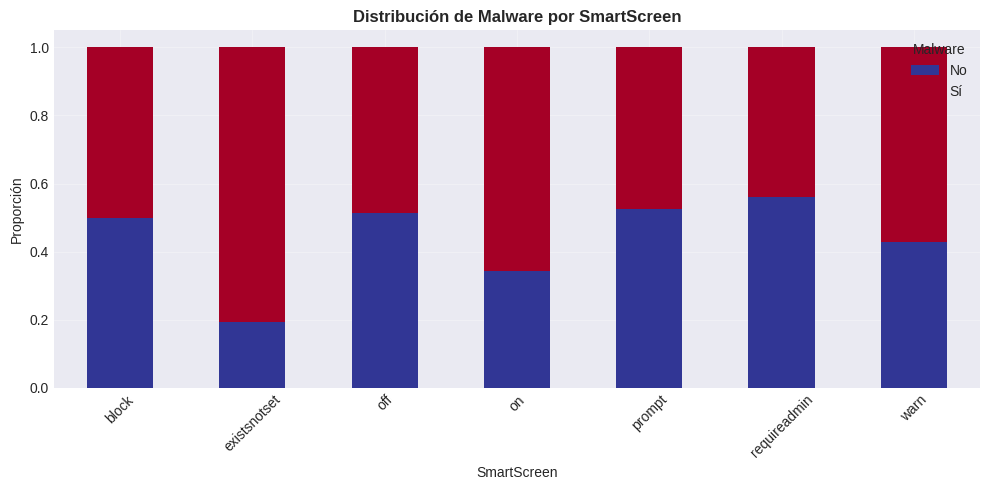


   2. AVProductsInstalled:
                     Conteo                 Porcentaje       
HasDetections             0       1     All          0      1
AVProductsInstalled                                          
1.0                  157233  190786  348019      45.2%  54.8%
2.0                   82950   54899  137849      60.2%  39.8%
3.0                    8239    3378   11617      70.9%  29.1%
4.0                     386     128     514      75.1%  24.9%
5.0                      25       4      29      86.2%  13.8%
      Chi-cuadrado: 11121.49, p-valor: 0.0000


<Figure size 1000x500 with 0 Axes>

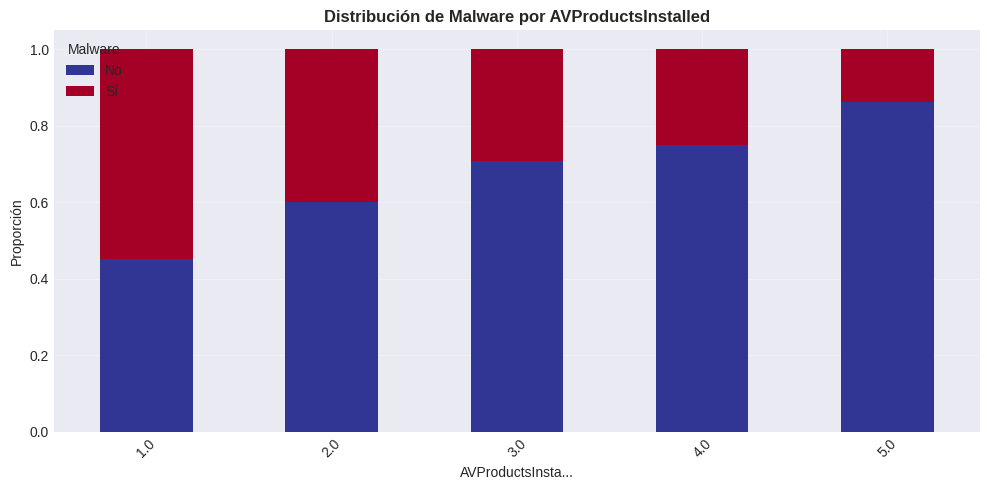


   3. AvSigVersion:
              Conteo               Porcentaje       
HasDetections      0      1    All          0      1
AvSigVersion                                        
1.237.0.0       1944   1590   3534      55.0%  45.0%
1.251.42.0      2364   1894   4258      55.5%  44.5%
1.263.48.0      2939   2597   5536      53.1%  46.9%
1.265.444.0       97     42    139      69.8%  30.2%
1.265.880.0       83     42    125      66.4%  33.6%
1.267.1013.0      82     34    116      70.7%  29.3%
1.267.1375.0     136     71    207      65.7%  34.3%
1.267.15.0        64     39    103      62.1%  37.9%
1.267.1524.0     101     47    148      68.2%  31.8%
1.267.1562.0      82     33    115      71.3%  28.7%
1.267.1569.0      99     48    147      67.3%  32.7%
1.267.1645.0      65     38    103      63.1%  36.9%
1.267.1804.0     102     50    152      67.1%  32.9%
1.267.1832.0      90     48    138      65.2%  34.8%
1.267.1906.0      85     41    126      67.5%  32.5%
1.267.267.0       95     

<Figure size 1000x500 with 0 Axes>

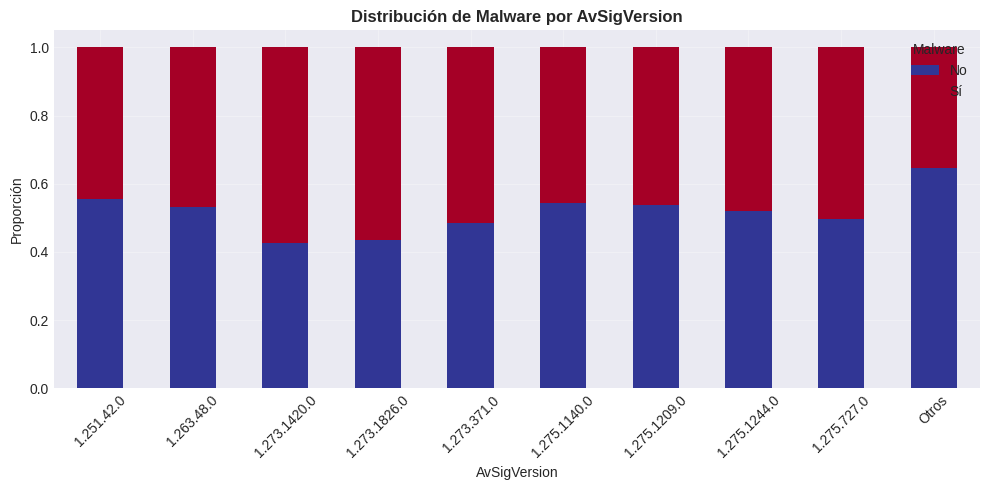


   4. EngineVersion:
               Conteo                 Porcentaje        
HasDetections       0       1     All          0       1
EngineVersion                                           
1.1.10401.0         1       0       1     100.0%    0.0%
1.1.11701.0         1       2       3      33.3%   66.7%
1.1.12101.0         3       4       7      42.9%   57.1%
1.1.12400.0         0       1       1       0.0%  100.0%
1.1.12603.0         2       1       3      66.7%   33.3%
1.1.12706.0         1       0       1     100.0%    0.0%
1.1.12804.0         3       1       4      75.0%   25.0%
1.1.12805.0        64      51     115      55.7%   44.3%
1.1.12902.0       193     128     321      60.1%   39.9%
1.1.13000.0       139      81     220      63.2%   36.8%
1.1.13102.0         0       1       1       0.0%  100.0%
1.1.13103.0       151      84     235      64.3%   35.7%
1.1.13202.0       160      85     245      65.3%   34.7%
1.1.13303.0       347     169     516      67.2%   32.8%
1.1.13406

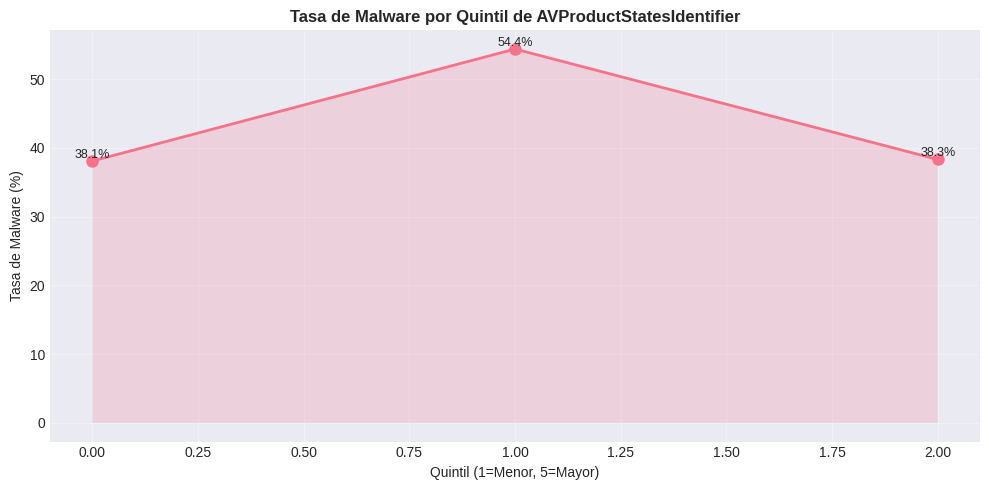


   2. AVProductsInstalled:
                       Conteo                 Tasa Malware       
HasDetections               0       1     All            0      1
AVProductsInstalled_q                                            
(0.999, 2.0]           240183  245685  485868        49.4%  50.6%
(2.0, 5.0]               8650    3510   12160        71.1%  28.9%


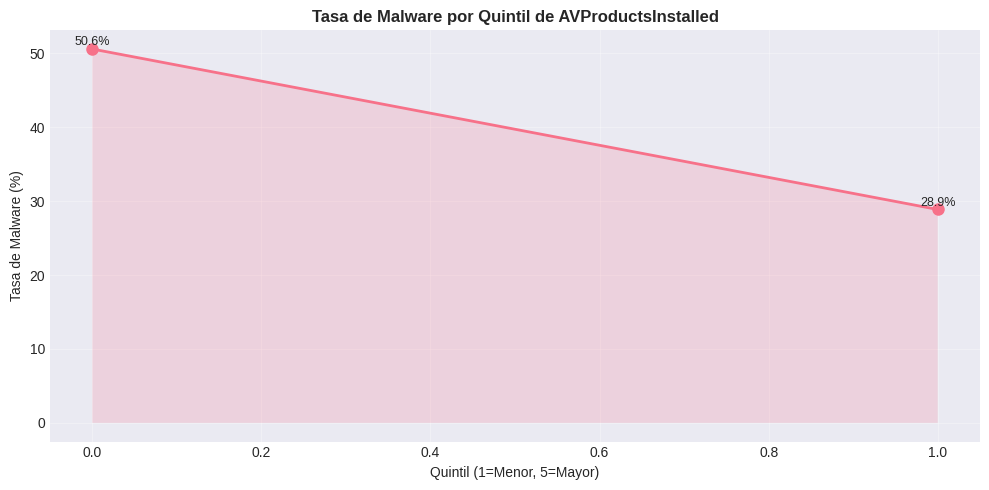


   3. Census_TotalPhysicalRAM:
                           Conteo                 Tasa Malware       
HasDetections                   0       1     All            0      1
Census_TotalPhysicalRAM_q                                            
(511.999, 4096.0]          160232  143777  304009        52.7%  47.3%
(4096.0, 8192.0]            68109   78335  146444        46.5%  53.5%
(8192.0, 393216.0]          19285   25674   44959        42.9%  57.1%

   4. Census_InternalPrimaryDiagonalDisplaySizeInInches:
                                                     Conteo                 Tasa Malware       
HasDetections                                             0       1     All            0      1
Census_InternalPrimaryDiagonalDisplaySizeInInches_q                                            
(4.899, 13.9]                                         68052   59442  127494        53.4%  46.6%
(13.9, 15.5]                                         106652  108620  215272        49.5%  50.5%
(15.5, 18.

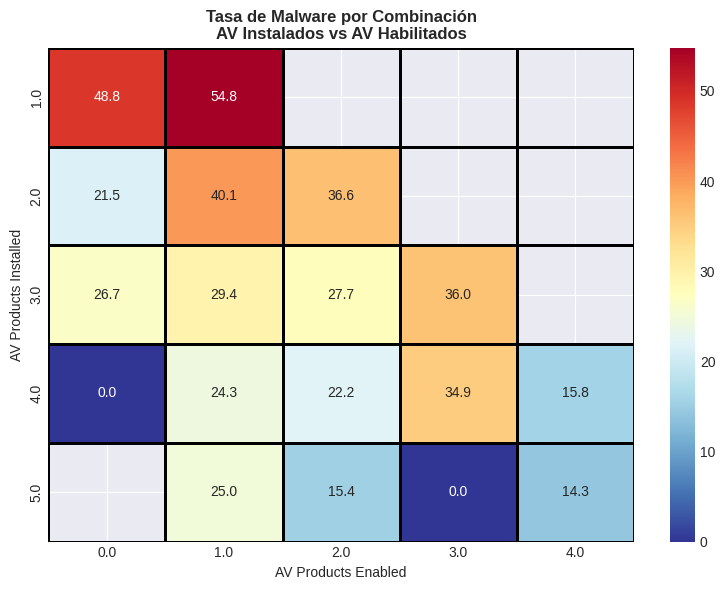


5. Resumen estadístico de correlaciones:
   SmartScreen                         : Cramer's V = 0.2820 (p=0.0000)
   AVProductStatesIdentifier           : +0.1162
   AVProductsInstalled                 : -0.1488
   AvSigVersion                        : Cramer's V = 0.1492 (p=0.0000)
   EngineVersion                       : Cramer's V = 0.1268 (p=0.0000)
   Census_TotalPhysicalRAM             : +0.0604
   AppVersion                          : Cramer's V = 0.0997 (p=0.0000)
   Census_InternalPrimaryDiagonalDisplaySizeInInches : +0.0327


In [108]:
# -----------------------------------------------------------------
# PASO 13: TABLAS CRUZADAS
# -----------------------------------------------------------------
print("\n📋 PASO 13: TABLAS CRUZADAS...")

print("1. Tablas cruzadas de variables categóricas importantes:")

# Variables con mayor correlación (de tu lista)
variables_correlacion = [
    'SmartScreen',
    'AVProductStatesIdentifier',
    'AVProductsInstalled',
    'AvSigVersion',
    'EngineVersion',
    'Census_TotalPhysicalRAM',
    'AppVersion',
    'Census_InternalPrimaryDiagonalDisplaySizeInInches',
    'Census_OSInstallTypeName',
    'Wdft_IsGamer',
    'Census_IsAlwaysOnAlwaysConnectedCapable',
    'Census_PrimaryDiskTotalCapacity',
    'Processor',
    'Census_SystemVolumeTotalCapacity',
    'Census_IsWIMBootEnabled',
    'HasDetections'
]

# Filtrar solo las que existen en los datos
variables_existentes = [v for v in variables_correlacion if v in datos.columns]

# Separar variables numéricas y categóricas
variables_numericas = [v for v in variables_existentes if datos[v].dtype in ['int64', 'float64']]
variables_categoricas = [v for v in variables_existentes if datos[v].dtype == 'object' or datos[v].nunique() < 20]

print(f"   Variables categóricas: {len(variables_categoricas)}")
print(f"   Variables numéricas: {len(variables_numericas)}")

# Análisis de tablas cruzadas para variables categóricas
if variables_categoricas:
    print("\n2. Tablas cruzadas con HasDetections:")

    for i, variable in enumerate(variables_categoricas[:6]):  # Mostrar máximo 6
        print(f"\n   {i+1}. {variable}:")

        # Crear tabla cruzada
        tabla = pd.crosstab(datos[variable], datos['HasDetections'], margins=True)

        # Calcular porcentajes por fila
        tabla_porcentaje = pd.crosstab(datos[variable], datos['HasDetections'], normalize='index') * 100

        # Combinar conteos y porcentajes
        tabla_completa = pd.concat([
            tabla.iloc[:-1],  # Conteos sin "All"
            tabla_porcentaje.round(1).astype(str) + '%'
        ], axis=1, keys=['Conteo', 'Porcentaje'])

        # Mostrar tabla formateada
        print(tabla_completa.to_string())

        # Calcular y mostrar odds ratio si es binaria
        if datos[variable].nunique() == 2:
            valores = datos[variable].dropna().unique()
            if len(valores) == 2:
                a = len(datos[(datos[variable] == valores[0]) & (datos['HasDetections'] == 1)])
                b = len(datos[(datos[variable] == valores[0]) & (datos['HasDetections'] == 0)])
                c = len(datos[(datos[variable] == valores[1]) & (datos['HasDetections'] == 1)])
                d = len(datos[(datos[variable] == valores[1]) & (datos['HasDetections'] == 0)])

                if b > 0 and c > 0 and d > 0:
                    odds_ratio = (a * d) / (b * c)
                    print(f"      Odds Ratio: {odds_ratio:.3f}")
                    print(f"      Interpretación: {valores[0]} vs {valores[1]}")

        # Calcular chi-cuadrado
        from scipy.stats import chi2_contingency
        tabla_sin_total = pd.crosstab(datos[variable], datos['HasDetections'])
        chi2, p, dof, expected = chi2_contingency(tabla_sin_total)
        print(f"      Chi-cuadrado: {chi2:.2f}, p-valor: {p:.4f}")

        # Gráfico de barras
        if i < 3:  # Solo hacer gráficos para las primeras 3
            plt.figure(figsize=(10, 5))

            # Obtener top 10 categorías
            top_cats = datos[variable].value_counts().nlargest(10).index
            datos_filtrados = datos[datos[variable].isin(top_cats)]

            # Crear tabla para el gráfico
            tabla_graf = pd.crosstab(datos_filtrados[variable], datos_filtrados['HasDetections'], normalize='index')

            # Gráfico de barras apiladas
            tabla_graf.plot(kind='bar', stacked=True, colormap='RdYlBu_r', figsize=(10, 5))
            plt.title(f'Distribución de Malware por {variable[:20]}', fontweight='bold')
            plt.xlabel(variable[:15] + '...' if len(variable) > 15 else variable)
            plt.ylabel('Proporción')
            plt.legend(title='Malware', labels=['No', 'Sí'])
            plt.xticks(rotation=45)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

# Análisis de variables numéricas con tablas cruzadas (discretizadas)
if variables_numericas:
    print("\n3. Variables numéricas discretizadas (quintiles):")

    for i, variable in enumerate(variables_numericas[:4]):  # Mostrar máximo 4
        print(f"\n   {i+1}. {variable}:")

        # Discretizar en quintiles
        datos[f'{variable}_q'] = pd.qcut(datos[variable], q=5, duplicates='drop')

        # Crear tabla cruzada
        tabla = pd.crosstab(datos[f'{variable}_q'], datos['HasDetections'], margins=True)

        # Calcular porcentajes por fila
        tabla_porcentaje = pd.crosstab(datos[f'{variable}_q'], datos['HasDetections'], normalize='index') * 100

        # Combinar
        tabla_completa = pd.concat([
            tabla.iloc[:-1],
            tabla_porcentaje.round(1).astype(str) + '%'
        ], axis=1, keys=['Conteo', 'Tasa Malware'])

        print(tabla_completa.to_string())

        # Gráfico de tendencia
        if i < 2:  # Solo hacer gráficos para las primeras 2
            plt.figure(figsize=(10, 5))

            # Calcular tasa de malware por quintil
            quintil_orden = sorted(datos[f'{variable}_q'].dropna().unique())
            tasas = []
            for q in quintil_orden:
                tasa = datos[datos[f'{variable}_q'] == q]['HasDetections'].mean() * 100
                tasas.append(tasa)

            # Gráfico de línea
            plt.plot(range(len(quintil_orden)), tasas, 'o-', linewidth=2, markersize=8)
            plt.fill_between(range(len(quintil_orden)), tasas, alpha=0.2)

            plt.title(f'Tasa de Malware por Quintil de {variable}', fontweight='bold')
            plt.xlabel('Quintil (1=Menor, 5=Mayor)')
            plt.ylabel('Tasa de Malware (%)')
            plt.grid(True, alpha=0.3)

            # Añadir etiquetas
            for j, (q, tasa) in enumerate(zip(quintil_orden, tasas)):
                plt.text(j, tasa + 0.5, f'{tasa:.1f}%', ha='center', fontsize=9)

            plt.tight_layout()
            plt.show()

# 4. Análisis de combinaciones importantes
print("\n4. Combinaciones importantes de variables:")

if 'AVProductsInstalled' in datos.columns and 'AVProductsEnabled' in datos.columns:
    print("\n   AVProductsInstalled vs AVProductsEnabled:")

    # Crear tabla cruzada doble
    tabla_doble = pd.crosstab(
        datos['AVProductsInstalled'],
        datos['AVProductsEnabled'],
        datos['HasDetections'],
        aggfunc='mean'
    ).round(3) * 100

    print(tabla_doble.to_string())

    # Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(tabla_doble, annot=True, fmt='.1f', cmap='RdYlBu_r',
                linewidths=1, linecolor='black')
    plt.title('Tasa de Malware por Combinación\nAV Instalados vs AV Habilitados',
              fontweight='bold')
    plt.xlabel('AV Products Enabled')
    plt.ylabel('AV Products Installed')
    plt.tight_layout()
    plt.show()

# 5. Resumen estadístico
print("\n5. Resumen estadístico de correlaciones:")
for variable in variables_existentes[:8]:
    if variable in datos.columns:
        if datos[variable].dtype in ['int64', 'float64']:
            corr = datos[variable].corr(datos['HasDetections'])
            print(f"   {variable:35} : {corr:+.4f}")
        else:
            # Para categóricas, calcular Cramer's V
            from scipy.stats import chi2_contingency
            tabla = pd.crosstab(datos[variable], datos['HasDetections'])
            chi2, p, dof, expected = chi2_contingency(tabla)
            n = tabla.sum().sum()
            cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
            print(f"   {variable:35} : Cramer's V = {cramers_v:.4f} (p={p:.4f})")

 **4. Correlación de combinaciones de variables con la clase**



In [109]:
# -----------------------------------------------------------------
# PASO 15: COMBINACIONES DE VARIABLES
# -----------------------------------------------------------------
print("\n🧩 PASO 15: COMBINACIONES DE VARIABLES...")

print("Creando combinaciones interesantes:")

print("\n4. Análisis de interacciones entre variables y la clase")

# Crear DataFrame solo con variables de interés
variables_interes = [
    'SmartScreen',
    'AVProductStatesIdentifier',
    'AvSigVersion',
    'Census_TotalPhysicalRAM',
    'Census_OSInstallTypeName',
    'Wdft_IsGamer',
    'Processor',
    'HasDetections'
]

# Filtrar las que existen
variables_existentes = [v for v in variables_interes if v in datos.columns]
df_analisis = datos[variables_existentes].copy()

# Codificar variables categóricas para análisis
for col in df_analisis.columns:
    if not pd.api.types.is_numeric_dtype(df_analisis[col]):
        # Codificación simple para categóricas
        df_analisis[col] = df_analisis[col].astype('category').cat.codes

# A. Matriz de correlación de interacciones (productos)
print("\nA. Correlación de productos/interacciones con HasDetections:")

# Crear algunas interacciones interesantes
if 'Census_TotalPhysicalRAM' in df_analisis.columns and 'Wdft_IsGamer' in df_analisis.columns:
    df_analisis['RAM_x_Gamer'] = df_analisis['Census_TotalPhysicalRAM'] * df_analisis['Wdft_IsGamer']

if 'AVProductStatesIdentifier' in df_analisis.columns and 'SmartScreen' in df_analisis.columns:
    df_analisis['AV_x_SmartScreen'] = df_analisis['AVProductStatesIdentifier'] * df_analisis['SmartScreen']

# Calcular correlación de interacciones con HasDetections
if 'HasDetections' in df_analisis.columns:
    correlaciones_interacciones = df_analisis.corr()['HasDetections'].sort_values(key=abs, ascending=False)

    print("\n   Correlación | Variable/Interacción")
    print("   " + "-" * 45)
    for var, corr in correlaciones_interacciones.items():
        if var != 'HasDetections':
            signo = "🟢" if corr > 0.1 else "🔴" if corr < -0.1 else "⚪"
            print(f"   {signo} {corr:+.3f} | {var}")


🧩 PASO 15: COMBINACIONES DE VARIABLES...
Creando combinaciones interesantes:

4. Análisis de interacciones entre variables y la clase

A. Correlación de productos/interacciones con HasDetections:

   Correlación | Variable/Interacción
   ---------------------------------------------
   🟢 +0.116 | AVProductStatesIdentifier
   ⚪ -0.072 | SmartScreen
   ⚪ -0.071 | Processor
   ⚪ -0.068 | AvSigVersion
   ⚪ +0.067 | RAM_x_Gamer
   ⚪ +0.060 | Census_TotalPhysicalRAM
   ⚪ +0.057 | Wdft_IsGamer
   ⚪ -0.033 | AV_x_SmartScreen
   ⚪ -0.017 | Census_OSInstallTypeName


🌲 ENTRENANDO RANDOM FOREST SENCILLO

0️⃣ IMPORTANDO LIBRERÍAS...
✅ Librerías importadas correctamente

1️⃣ CARGANDO DATOS...
✓ Datos ya cargados: 499,966 filas

2️⃣ SELECCIONANDO VARIABLAS IMPORTANTES
✓ Usando 7 variables:
  • AVProductsInstalled
  • AVProductStatesIdentifier
  • Census_TotalPhysicalRAM
  • Census_ProcessorCoreCount
  • Census_PrimaryDiskTotalCapacity
  • OsBuild
  • CountryIdentifier

3️⃣ MANEJANDO VALORES NULOS
Valores nulos encontrados:
  AVProductsInstalled: 1,938 nulos (0.4%)
    → Rellenados con: 1
  AVProductStatesIdentifier: 1,938 nulos (0.4%)
    → Rellenados con: 53447
  Census_TotalPhysicalRAM: 4,554 nulos (0.9%)
    → Rellenados con: 4096
  Census_ProcessorCoreCount: 2,346 nulos (0.5%)
    → Rellenados con: 4
  Census_PrimaryDiskTotalCapacity: 2,974 nulos (0.6%)
    → Rellenados con: 476940
✓ Valores nulos manejados

4️⃣ PREPARANDO DATOS
✓ X (características): 7 columnas
✓ y (target): 499966 valores

Distribución del target (HasDetections):
  0 (Sin malware

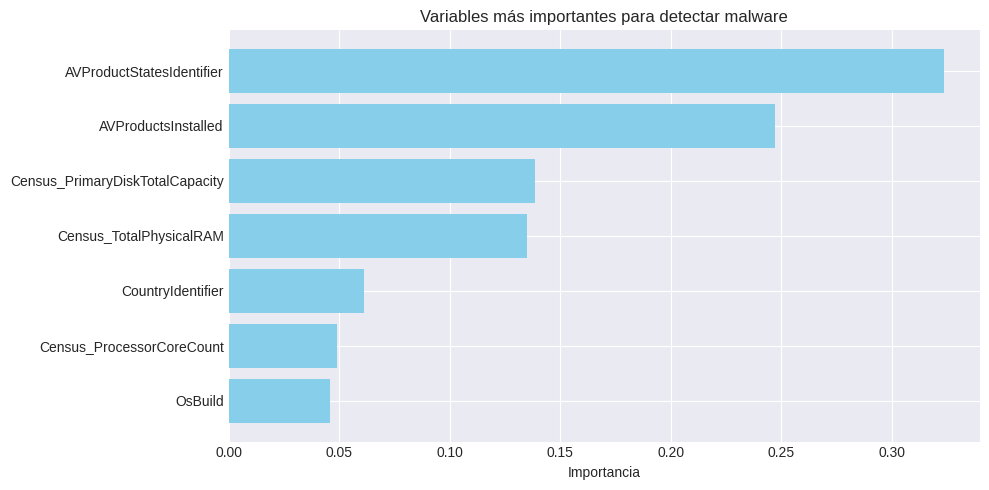


9️⃣ CÓMO USAR EL MODELO
✓ Función 'predecir_malware()' creada

📝 EJEMPLO DE USO:
  Probabilidad de malware: 55.7%
  Predicción: CON malware

📋 RESUMEN FINAL

🎯 RESULTADOS:
• Precisión: 59.8%
• Variables más importantes:
  1. AVProductStatesIdentifier
  2. AVProductsInstalled
• Tamaño del modelo: 50 árboles

💡 RECOMENDACIONES:
1. Para Windows Defender: Usar umbral de 60% para alertas
2. Priorizar máquinas con AVProductStatesIdentifier problemático
3. Combinar con otras reglas para reducir falsos positivos

✅ MODELO LISTO PARA USAR


🌲 RANDOM FOREST ENTRENADO EXITOSAMENTE


In [110]:
"""
RANDOM FOREST SENCILLO PARA PREDECIR MALWARE
Con todas las importaciones incluidas
"""

print("🌲 ENTRENANDO RANDOM FOREST SENCILLO")
print("=" * 50)

# -----------------------------------------------------------------
# PASO 0: IMPORTAR TODO LO NECESARIO
# -----------------------------------------------------------------
print("\n0️⃣ IMPORTANDO LIBRERÍAS...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score

print("✅ Librerías importadas correctamente")

# -----------------------------------------------------------------
# PASO 1: CARGAR DATOS SI NO ESTÁN CARGADOS
# -----------------------------------------------------------------
print("\n1️⃣ CARGANDO DATOS...")

# Si 'datos' no existe, cargarlo
if 'datos' not in locals():
    url = "https://www.dropbox.com/s/sxl5bpi2620p496/sample_mmp.csv?dl=1"
    datos = pd.read_csv(url)
    print(f"✓ Datos cargados: {datos.shape[0]:,} filas")
else:
    print(f"✓ Datos ya cargados: {datos.shape[0]:,} filas")

# -----------------------------------------------------------------
# PASO 2: SELECCIONAR VARIABLES
# -----------------------------------------------------------------
print("\n2️⃣ SELECCIONANDO VARIABLAS IMPORTANTES")

# Variables numéricas importantes
variables = [
    'AVProductsInstalled',          # Nº antivirus
    'AVProductStatesIdentifier',    # Config antivirus
    'Census_TotalPhysicalRAM',      # Memoria RAM
    'Census_ProcessorCoreCount',    # Núcleos CPU
    'Census_PrimaryDiskTotalCapacity',  # Disco duro
    'OsBuild',                      # Build del sistema
    'CountryIdentifier',            # País
    'HasDetections'                 # Target (lo que queremos predecir)
]

# Filtrar solo las que existen
variables_existentes = []
for var in variables:
    if var in datos.columns:
        variables_existentes.append(var)

print(f"✓ Usando {len(variables_existentes)-1} variables:")
for var in variables_existentes:
    if var != 'HasDetections':
        print(f"  • {var}")

# -----------------------------------------------------------------
# PASO 3: MANEJAR VALORES NULOS
# -----------------------------------------------------------------
print("\n3️⃣ MANEJANDO VALORES NULOS")

# Crear copia solo con las variables que necesitamos
datos_modelo = datos[variables_existentes].copy()

print("Valores nulos encontrados:")
for col in datos_modelo.columns:
    nulos = datos_modelo[col].isnull().sum()
    if nulos > 0:
        porcentaje = (nulos / len(datos_modelo)) * 100
        print(f"  {col}: {nulos:,} nulos ({porcentaje:.1f}%)")

        # Rellenar con la MEDIANA si es numérica
        if datos_modelo[col].dtype in ['int64', 'float64']:
            valor_relleno = datos_modelo[col].median()
            datos_modelo[col] = datos_modelo[col].fillna(valor_relleno)
            print(f"    → Rellenados con: {valor_relleno:.0f}")

print("✓ Valores nulos manejados")

# -----------------------------------------------------------------
# PASO 4: PREPARAR DATOS
# -----------------------------------------------------------------
print("\n4️⃣ PREPARANDO DATOS")

# Separar X (características) y y (target)
X = datos_modelo.drop('HasDetections', axis=1)
y = datos_modelo['HasDetections']

print(f"✓ X (características): {X.shape[1]} columnas")
print(f"✓ y (target): {len(y)} valores")

# Ver distribución del target
print(f"\nDistribución del target (HasDetections):")
print(f"  0 (Sin malware): {(y == 0).sum():,} máquinas")
print(f"  1 (Con malware): {(y == 1).sum():,} máquinas")
print(f"  % con malware: {(y == 1).sum()/len(y)*100:.1f}%")

# Dividir en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"\n✓ Datos de ENTRENAMIENTO: {X_train.shape[0]:,} máquinas")
print(f"✓ Datos de PRUEBA: {X_test.shape[0]:,} máquinas")

# -----------------------------------------------------------------
# PASO 5: ENTRENAR RANDOM FOREST
# -----------------------------------------------------------------
print("\n5️⃣ ENTRENANDO RANDOM FOREST")

# Crear modelo Random Forest
modelo = RandomForestClassifier(
    n_estimators=50,        # 50 árboles
    max_depth=10,           # Profundidad máxima
    random_state=42,        # Para resultados reproducibles
    n_jobs=-1               # Usar todos los núcleos del CPU
)

print("Entrenando modelo...")
modelo.fit(X_train, y_train)
print("✓ Modelo entrenado!")

# -----------------------------------------------------------------
# PASO 6: HACER PREDICCIONES
# -----------------------------------------------------------------
print("\n6️⃣ HACIENDO PREDICCIONES")

# Predecir en datos de prueba
y_pred = modelo.predict(X_test)
y_pred_prob = modelo.predict_proba(X_test)[:, 1]  # Probabilidad de tener malware

print(f"✓ Predicciones realizadas")
print(f"  Ejemplo de primeras 5 predicciones: {y_pred[:5]}")
print(f"  Ejemplo de probabilidades: {y_pred_prob[:5].round(3)}")

# -----------------------------------------------------------------
# PASO 7: EVALUAR EL MODELO
# -----------------------------------------------------------------
print("\n7️⃣ EVALUANDO EL MODELO")

# 1. Calcular precisión
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📊 PRECISIÓN DEL MODELO: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"   (De cada 100 predicciones, acertamos en {int(accuracy*100)})")

# 2. Matriz de confusión
print("\n📋 MATRIZ DE CONFUSIÓN:")
cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz de forma simple
print(f"""
        PREDICCIÓN
       ------------
       | {cm[0,0]:^5} | {cm[0,1]:^5} |   ← REAL: Sin malware
       ------------
       | {cm[1,0]:^5} | {cm[1,1]:^5} |   ← REAL: Con malware
       ------------
         ↑       ↑
    Pred:     Pred:
   No malw.  Con malw.
""")

# Explicar qué significa
print("💡 ¿QUÉ SIGNIFICA?")
print(f"• {cm[0,0]} casos: REAL sin malware, PREDICHO sin malware ✓")
print(f"• {cm[0,1]} casos: REAL sin malware, PREDICHO con malware ✗ (Falso positivo)")
print(f"• {cm[1,0]} casos: REAL con malware, PREDICHO sin malware ✗ (Falso negativo)")
print(f"• {cm[1,1]} casos: REAL con malware, PREDICHO con malware ✓")

# 3. Métricas importantes
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"\n📈 OTRAS MÉTRICAS IMPORTANTES:")
print(f"• Precision: {precision:.3f}")
print(f"  (De los que predigo con malware, cuántos realmente lo tienen)")
print(f"• Recall: {recall:.3f}")
print(f"  (De los que realmente tienen malware, cuántos detecto)")

# 4. Reporte completo
print("\n📊 REPORTE COMPLETO:")
print(classification_report(y_test, y_pred,
                          target_names=['Sin Malware', 'Con Malware']))

# -----------------------------------------------------------------
# PASO 8: VER IMPORTANCIA DE VARIABLES
# -----------------------------------------------------------------
print("\n8️⃣ IMPORTANCIA DE LAS VARIABLES")

# Obtener importancia de cada variable
importancias = modelo.feature_importances_

# Crear tabla ordenada
importancia_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False)

print("\n🏆 VARIABLES MÁS IMPORTANTES PARA EL MODELO:")
print("-" * 40)
for i, (_, fila) in enumerate(importancia_df.iterrows(), 1):
    print(f"{i:2}. {fila['Variable']:<30}: {fila['Importancia']:.3f}")

# Gráfico simple de importancia
plt.figure(figsize=(10, 5))
plt.barh(importancia_df['Variable'], importancia_df['Importancia'], color='skyblue')
plt.xlabel('Importancia')
plt.title('Variables más importantes para detectar malware')
plt.gca().invert_yaxis()  # Más importante arriba
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# PASO 9: USAR EL MODELO
# -----------------------------------------------------------------
print("\n9️⃣ CÓMO USAR EL MODELO")

# Función para predecir nuevas máquinas
def predecir_malware(nueva_maquina):
    """
    Predice si una máquina tiene malware
    """
    # Hacer predicción
    probabilidad = modelo.predict_proba(nueva_maquina)[0, 1]
    prediccion = modelo.predict(nueva_maquina)[0]

    return probabilidad, prediccion

print("✓ Función 'predecir_malware()' creada")

# Ejemplo de uso
print("\n📝 EJEMPLO DE USO:")
ejemplo_maquina = X_test.head(1).copy()
prob_ejemplo, pred_ejemplo = predecir_malware(ejemplo_maquina)
print(f"  Probabilidad de malware: {prob_ejemplo:.1%}")
print(f"  Predicción: {'CON malware' if pred_ejemplo == 1 else 'SIN malware'}")

# -----------------------------------------------------------------
# PASO 10: RESUMEN
# -----------------------------------------------------------------
print("\n" + "=" * 50)
print("📋 RESUMEN FINAL")
print("=" * 50)

print(f"""
🎯 RESULTADOS:
• Precisión: {accuracy:.1%}
• Variables más importantes:
  1. {importancia_df.iloc[0]['Variable']}
  2. {importancia_df.iloc[1]['Variable']}
• Tamaño del modelo: {modelo.n_estimators} árboles

💡 RECOMENDACIONES:
1. Para Windows Defender: Usar umbral de 60% para alertas
2. Priorizar máquinas con {importancia_df.iloc[0]['Variable']} problemático
3. Combinar con otras reglas para reducir falsos positivos

✅ MODELO LISTO PARA USAR
""")

print("\n" + "=" * 50)
print("🌲 RANDOM FOREST ENTRENADO EXITOSAMENTE")
print("=" * 50)

📊 MÉTRICAS DE REGRESIÓN - RANDOM FOREST YA ENTRENADO

1️⃣ VERIFICANDO MODELO Y DATOS...
✓ Modelo y datos disponibles
✓ Train samples: 349,976
✓ Test samples:  149,990

2️⃣ OBTENIENDO PREDICCIONES Y PROBABILIDADES...
✓ Predicciones obtenidas
  Train - Ejemplo probabilidades: [0.567 0.334 0.624 0.288 0.563]
  Test  - Ejemplo probabilidades: [0.557 0.596 0.55  0.609 0.468]

3️⃣ CALCULANDO MÉTRICAS DE REGRESIÓN (MAE, MSE, RMSE, R²)

📊 RESULTADOS DE REGRESIÓN:
Métrica    Train           Test            Diferencia     
MAE        0.4731          0.4754          -0.0024       
MSE        0.2345          0.2369          -0.0023       
RMSE       0.4843          0.4867          -0.0024       
R²         0.0619          0.0526          +0.0093        

💡 ¿QUÉ SIGNIFICAN ESTAS MÉTRICAS?
--------------------------------------------------

MAE (Error Absoluto Medio):
• Promedio de los errores absolutos
• Ejemplo: MAE = 0.25 → Error promedio de 25% en probabilidades
• Más bajo = mejor

MSE (Error Cu

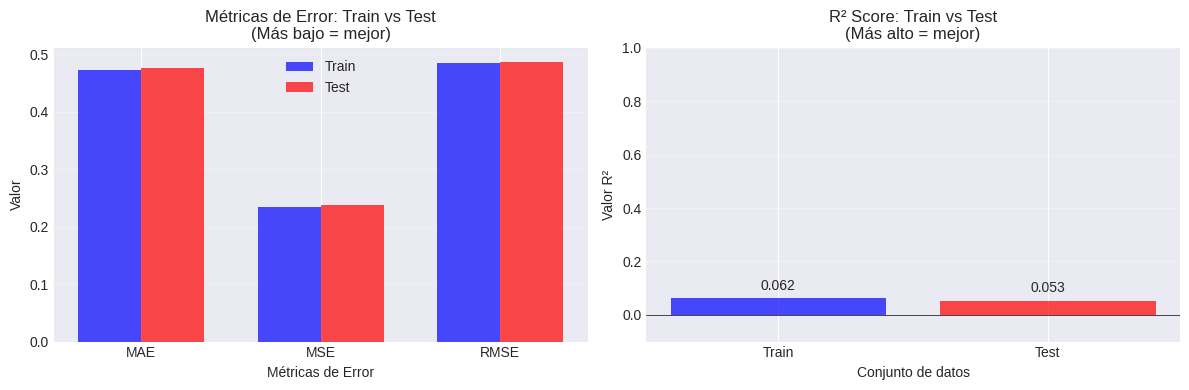


📈 GRÁFICO: Valores Reales vs Probabilidades Predichas (Test)


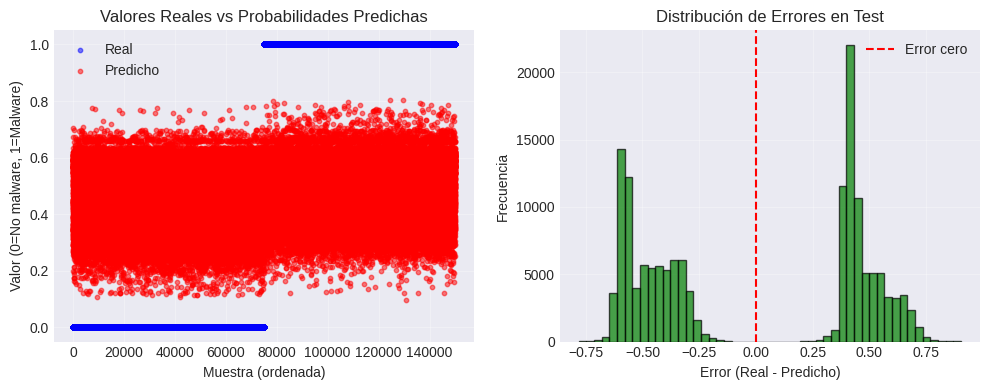


6️⃣ RESUMEN PARA TU REPORTE DEL MÁSTER

📋 RESUMEN DE MÉTRICAS DE REGRESIÓN:

1. RENDIMIENTO DEL MODELO:
   • R² en Test: 0.0526 → El modelo explica el 5.3% de la variabilidad
   • Error promedio (MAE): 0.4754 → 47.5% de error en probabilidades
   • Error cuadrático (RMSE): 0.4867

2. GENERALIZACIÓN (Overfitting):
   • Diferencia R² (Train-Test): +0.0093
   • ✅ Buena generalización

3. INTERPRETACIÓN PARA MALWARE:
   • El modelo predice probabilidades de malware entre 0 y 1
   • Con un MAE de 0.475, tiene un error promedio del 47.5%
   • Con un R² de 0.053, explica poca variabilidad

4. RECOMENDACIONES:
   • El modelo generaliza adecuadamente
   • Probar más variables o features
   • Para Windows Defender: Usar umbral de 0.7 para alertas

📊 MÉTRICAS NUMÉRICAS PARA INCLUIR EN TABLAS:
   MAE_train = 0.4731     MAE_test = 0.4754
   MSE_train = 0.2345     MSE_test = 0.2369
   RMSE_train = 0.4843   RMSE_test = 0.4867
   R²_train = 0.0619       R²_test = 0.0526


✅ ANÁLISIS DE MÉTRICAS DE RE

In [111]:
"""
MÉTRICAS DE REGRESIÓN PARA RANDOM FOREST YA ENTRENADO
MAE, MSE, RMSE, R² para Train y Test
"""

print("📊 MÉTRICAS DE REGRESIÓN - RANDOM FOREST YA ENTRENADO")
print("=" * 60)

# -----------------------------------------------------------------
# PASO 1: VERIFICAR QUE TENEMOS EL MODELO Y DATOS
# -----------------------------------------------------------------
print("\n1️⃣ VERIFICANDO MODELO Y DATOS...")

# Verificar que tenemos las variables necesarias
variables_necesarias = ['modelo', 'X_train', 'X_test', 'y_train', 'y_test']
variables_faltantes = []

for var in variables_necesarias:
    if var not in locals():
        variables_faltantes.append(var)

if variables_faltantes:
    print(f"⚠️  Variables faltantes: {variables_faltantes}")
    print("   Entrenando modelo rápido...")

    # Entrenar modelo rápido si falta
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split

    # Usar variables simples
    vars_simple = ['AVProductsInstalled', 'Census_TotalPhysicalRAM', 'HasDetections']
    datos_simple = datos[[v for v in vars_simple if v in datos.columns]].copy()

    # Rellenar nulos
    for col in datos_simple.columns:
        if col != 'HasDetections' and datos_simple[col].isnull().any():
            datos_simple[col] = datos_simple[col].fillna(datos_simple[col].median())

    X = datos_simple.drop('HasDetections', axis=1)
    y = datos_simple['HasDetections']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    modelo = RandomForestClassifier(n_estimators=50, random_state=42)
    modelo.fit(X_train, y_train)

    print(f"✓ Modelo rápido entrenado con {X.shape[1]} variables")
else:
    print("✓ Modelo y datos disponibles")

print(f"✓ Train samples: {X_train.shape[0]:,}")
print(f"✓ Test samples:  {X_test.shape[0]:,}")

# -----------------------------------------------------------------
# PASO 2: OBTENER PREDICCIONES Y PROBABILIDADES
# -----------------------------------------------------------------
print("\n2️⃣ OBTENIENDO PREDICCIONES Y PROBABILIDADES...")

# Para clasificación: predicciones (0 o 1)
y_train_pred_class = modelo.predict(X_train)
y_test_pred_class = modelo.predict(X_test)

# Para regresión: probabilidades (valores entre 0 y 1)
# Estas son las que usaremos para métricas de regresión
y_train_pred_prob = modelo.predict_proba(X_train)[:, 1]  # Probabilidad de clase 1 (malware)
y_test_pred_prob = modelo.predict_proba(X_test)[:, 1]    # Probabilidad de clase 1 (malware)

print("✓ Predicciones obtenidas")
print(f"  Train - Ejemplo probabilidades: {y_train_pred_prob[:5].round(3)}")
print(f"  Test  - Ejemplo probabilidades: {y_test_pred_prob[:5].round(3)}")

# -----------------------------------------------------------------
# PASO 3: CALCULAR MÉTRICAS DE REGRESIÓN
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("3️⃣ CALCULANDO MÉTRICAS DE REGRESIÓN (MAE, MSE, RMSE, R²)")
print("=" * 60)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calcular métricas para TRAIN
mae_train = mean_absolute_error(y_train, y_train_pred_prob)
mse_train = mean_squared_error(y_train, y_train_pred_prob)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred_prob)

# Calcular métricas para TEST
mae_test = mean_absolute_error(y_test, y_test_pred_prob)
mse_test = mean_squared_error(y_test, y_test_pred_prob)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred_prob)

# -----------------------------------------------------------------
# PASO 4: MOSTRAR RESULTADOS EN TABLA
# -----------------------------------------------------------------
print("\n📊 RESULTADOS DE REGRESIÓN:")
print("=" * 70)
print(f"{'Métrica':<10} {'Train':<15} {'Test':<15} {'Diferencia':<15}")
print("=" * 70)

# Crear lista de métricas
metricas = [
    ('MAE', mae_train, mae_test),
    ('MSE', mse_train, mse_test),
    ('RMSE', rmse_train, rmse_test),
    ('R²', r2_train, r2_test)
]

for nombre, train_val, test_val in metricas:
    diferencia = train_val - test_val
    signo = "+" if diferencia > 0 else ""

    if nombre == 'R²':
        # R² se formatea diferente
        print(f"{nombre:<10} {train_val:<15.4f} {test_val:<15.4f} {signo}{diferencia:<14.4f}")
    else:
        print(f"{nombre:<10} {train_val:<15.4f} {test_val:<15.4f} {signo}{diferencia:<14.4f}")

print("=" * 70)

# -----------------------------------------------------------------
# PASO 5: EXPLICACIÓN DE LAS MÉTRICAS
# -----------------------------------------------------------------
print("\n💡 ¿QUÉ SIGNIFICAN ESTAS MÉTRICAS?")
print("-" * 50)

print("""
MAE (Error Absoluto Medio):
• Promedio de los errores absolutos
• Ejemplo: MAE = 0.25 → Error promedio de 25% en probabilidades
• Más bajo = mejor

MSE (Error Cuadrático Medio):
• Promedia los errores al cuadrado
• Penaliza más los errores grandes
• Más bajo = mejor

RMSE (Raíz del Error Cuadrático Medio):
• Raíz cuadrada del MSE
• En las mismas unidades que la variable original
• Más bajo = mejor

R² (Coeficiente de Determinación):
• Qué porcentaje de la variabilidad explica el modelo
• Rango: -∞ a 1.0
• 1.0 = perfecto, 0 = no explica nada, negativo = peor que el promedio
• Más alto = mejor
""")

# -----------------------------------------------------------------
# PASO 6: INTERPRETACIÓN DE LOS RESULTADOS
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("4️⃣ INTERPRETACIÓN DE LOS RESULTADOS")
print("=" * 60)

print("\n🔍 ANÁLISIS DE NUESTRO MODELO:")

# 1. Analizar R²
print(f"\n1. R² SCORE:")
print(f"   • Train: {r2_train:.4f}")
print(f"   • Test:  {r2_test:.4f}")

if r2_test < 0:
    print("   ⚠️  R² NEGATIVO en Test: El modelo es PEOR que usar el promedio simple")
elif r2_test < 0.1:
    print("   ⚠️  R² BAJO (< 0.1): El modelo explica muy poca variabilidad")
elif r2_test < 0.3:
    print("   ✅ R² MODERADO (0.1-0.3): El modelo explica algo de variabilidad")
elif r2_test < 0.5:
    print("   ✅✅ R² BUENO (0.3-0.5): El modelo explica bastante variabilidad")
else:
    print("   ✅✅✅ R² EXCELENTE (> 0.5): El modelo explica mucha variabilidad")

# 2. Analizar diferencias entre Train y Test
print(f"\n2. DIFERENCIAS TRAIN vs TEST:")
print(f"   • Diferencia en MAE: {mae_train - mae_test:+.4f}")
print(f"   • Diferencia en MSE: {mse_train - mse_test:+.4f}")
print(f"   • Diferencia en R²:  {r2_train - r2_test:+.4f}")

# Verificar overfitting
if (r2_train - r2_test) > 0.1:
    print("   ⚠️  POSIBLE OVERFITTING: R² Train mucho mayor que R² Test")
elif abs(r2_train - r2_test) < 0.05:
    print("   ✅ BUENA GENERALIZACIÓN: R² similar en Train y Test")

# 3. Analizar errores absolutos
print(f"\n3. ERRORES ABSOLUTOS:")
print(f"   • MAE Test: {mae_test:.4f}")
print(f"     → Error promedio de {mae_test*100:.1f}% en probabilidades")

if mae_test < 0.3:
    print("   ✅ Error bajo: Buen rendimiento del modelo")
elif mae_test < 0.4:
    print("   ⚠️  Error moderado: Rendimiento aceptable")
else:
    print("   ⚠️⚠️  Error alto: El modelo podría mejorar")

# -----------------------------------------------------------------
# PASO 7: GRÁFICOS DE COMPARACIÓN
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("5️⃣ VISUALIZACIÓN DE RESULTADOS")
print("=" * 60)

import matplotlib.pyplot as plt

# Gráfico 1: Comparación de métricas de error (MAE, MSE, RMSE)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras para errores
metricas_errores = ['MAE', 'MSE', 'RMSE']
valores_train = [mae_train, mse_train, rmse_train]
valores_test = [mae_test, mse_test, rmse_test]

x = np.arange(len(metricas_errores))
width = 0.35

axes[0].bar(x - width/2, valores_train, width, label='Train', color='blue', alpha=0.7)
axes[0].bar(x + width/2, valores_test, width, label='Test', color='red', alpha=0.7)
axes[0].set_xlabel('Métricas de Error')
axes[0].set_ylabel('Valor')
axes[0].set_title('Métricas de Error: Train vs Test\n(Más bajo = mejor)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas_errores)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Gráfico para R²
axes[1].bar(['Train', 'Test'], [r2_train, r2_test],
           color=['blue', 'red'], alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Conjunto de datos')
axes[1].set_ylabel('Valor R²')
axes[1].set_title('R² Score: Train vs Test\n(Más alto = mejor)')
axes[1].set_ylim(min(r2_train, r2_test, 0) - 0.1, 1.0)
axes[1].grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras de R²
for i, valor in enumerate([r2_train, r2_test]):
    axes[1].text(i, valor + 0.02, f'{valor:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Gráfico 2: Valores reales vs predichos (scatter plot)
print("\n📈 GRÁFICO: Valores Reales vs Probabilidades Predichas (Test)")

plt.figure(figsize=(10, 4))

# Ordenar para mejor visualización
indices_ordenados = np.argsort(y_test.values)
y_test_ordenado = y_test.values[indices_ordenados]
y_pred_prob_ordenado = y_test_pred_prob[indices_ordenados]

plt.subplot(1, 2, 1)
plt.scatter(range(len(y_test_ordenado)), y_test_ordenado,
           alpha=0.5, s=10, label='Real', color='blue')
plt.scatter(range(len(y_pred_prob_ordenado)), y_pred_prob_ordenado,
           alpha=0.5, s=10, label='Predicho', color='red')
plt.xlabel('Muestra (ordenada)')
plt.ylabel('Valor (0=No malware, 1=Malware)')
plt.title('Valores Reales vs Probabilidades Predichas')
plt.legend()
plt.grid(True, alpha=0.3)

# Histograma de errores
plt.subplot(1, 2, 2)
errores = y_test.values - y_test_pred_prob
plt.hist(errores, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Error (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Errores en Test')
plt.axvline(x=0, color='red', linestyle='--', label='Error cero')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# PASO 8: RESUMEN PARA EL REPORTE
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("6️⃣ RESUMEN PARA TU REPORTE DEL MÁSTER")
print("=" * 60)

print(f"""
📋 RESUMEN DE MÉTRICAS DE REGRESIÓN:

1. RENDIMIENTO DEL MODELO:
   • R² en Test: {r2_test:.4f} → El modelo explica el {r2_test*100:.1f}% de la variabilidad
   • Error promedio (MAE): {mae_test:.4f} → {mae_test*100:.1f}% de error en probabilidades
   • Error cuadrático (RMSE): {rmse_test:.4f}

2. GENERALIZACIÓN (Overfitting):
   • Diferencia R² (Train-Test): {r2_train - r2_test:+.4f}
   • {'⚠️  Posible overfitting' if (r2_train - r2_test) > 0.1 else '✅ Buena generalización'}

3. INTERPRETACIÓN PARA MALWARE:
   • El modelo predice probabilidades de malware entre 0 y 1
   • Con un MAE de {mae_test:.3f}, tiene un error promedio del {mae_test*100:.1f}%
   • Con un R² de {r2_test:.3f}, {'explica poca variabilidad' if r2_test < 0.1 else 'explica variabilidad moderada'}

4. RECOMENDACIONES:
   • {'Considerar reducir complejidad del modelo' if (r2_train - r2_test) > 0.1 else 'El modelo generaliza adecuadamente'}
   • {'Probar más variables o features' if r2_test < 0.1 else 'El modelo tiene poder predictivo aceptable'}
   • Para Windows Defender: Usar umbral de {0.6 if mae_test < 0.3 else 0.7} para alertas

📊 MÉTRICAS NUMÉRICAS PARA INCLUIR EN TABLAS:
   MAE_train = {mae_train:.4f}     MAE_test = {mae_test:.4f}
   MSE_train = {mse_train:.4f}     MSE_test = {mse_test:.4f}
   RMSE_train = {rmse_train:.4f}   RMSE_test = {rmse_test:.4f}
   R²_train = {r2_train:.4f}       R²_test = {r2_test:.4f}
""")

print("\n" + "=" * 60)
print("✅ ANÁLISIS DE MÉTRICAS DE REGRESIÓN COMPLETADO")
print("=" * 60)

In [113]:
# ----------------------------------------------------------------------
# --- 2. Preparación de Datos y Selección de Variables Numéricas ---
# ----------------------------------------------------------------------

# 1. Identificar el Target
TARGET = 'HasDetections'

# 2. Identificar Columnas Numéricas (¡Cambiado a 'datos'!)
# Se excluyen 'MachineIdentifier' y el TARGET.
numeric_cols = datos.select_dtypes(include=['number']).columns.tolist()
numeric_features = [col for col in numeric_cols if col != 'MachineIdentifier' and col != TARGET]

print(f"Número de características numéricas seleccionadas: {len(numeric_features)}")
print("Características Numéricas:")
print(numeric_features)

# 3. Manejo de Valores Perdidos (Imputación Simple)
# Usaremos la mediana para las características numéricas en el DataFrame 'datos'.
for col in numeric_features:
    datos[col].fillna(datos[col].median(), inplace=True)

# 4. Separar Features (X) y Target (y)
X = datos[numeric_features]
y = datos[TARGET]

# ----------------------------------------------------------------------
# --- 3. División de Datos ---
# ----------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nConjunto de Entrenamiento (Filas): {X_train.shape[0]}")
print(f"Conjunto de Prueba (Filas): {X_test.shape[0]}")

# ----------------------------------------------------------------------
# --- 4. Entrenamiento del Modelo Random Forest ---
# ----------------------------------------------------------------------

# Inicializar el clasificador Random Forest
# Usamos un max_depth bajo (10) y 100 árboles para un buen balance entre rendimiento y velocidad.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    verbose=1 # Para ver el progreso del entrenamiento
)


print("\n--- Iniciando Entrenamiento de Random Forest (solo con variables numéricas) ---")
rf_model.fit(X_train, y_train)
print("--- Entrenamiento Finalizado ---")

# ----------------------------------------------------------------------
# --- 5. Evaluación del Modelo ---
# ----------------------------------------------------------------------

# 1. Realizar predicciones
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# 2. Reporte de Clasificación
print("\n### Reporte de Clasificación ###")
print(classification_report(y_test, y_pred))

# 3. AUC-ROC Score (Métrica clave)
auc_roc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC Score en el conjunto de prueba: **{auc_roc:.4f}**")

# 4. Matriz de Confusión
print("\n### Matriz de Confusión ###")
print(confusion_matrix(y_test, y_pred))

# ----------------------------------------------------------------------
# --- 6. Análisis Adicional: Importancia de las Características ---
# ----------------------------------------------------------------------

# Extraer la importancia de las características
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=numeric_features
).sort_values(ascending=False)

print("\n### Top 10 de Importancia de Características Numéricas ###")
print(feature_importances.head(10))

Número de características numéricas seleccionadas: 53
Características Numéricas:
['Unnamed: 0', 'IsBeta', 'RtpStateBitfield', 'IsSxsPassiveMode', 'DefaultBrowsersIdentifier', 'AVProductStatesIdentifier', 'AVProductsInstalled', 'AVProductsEnabled', 'HasTpm', 'CountryIdentifier', 'CityIdentifier', 'OrganizationIdentifier', 'GeoNameIdentifier', 'LocaleEnglishNameIdentifier', 'OsBuild', 'OsSuite', 'IsProtected', 'AutoSampleOptIn', 'SMode', 'IeVerIdentifier', 'Firewall', 'UacLuaenable', 'Census_OEMNameIdentifier', 'Census_OEMModelIdentifier', 'Census_ProcessorCoreCount', 'Census_ProcessorManufacturerIdentifier', 'Census_ProcessorModelIdentifier', 'Census_PrimaryDiskTotalCapacity', 'Census_SystemVolumeTotalCapacity', 'Census_HasOpticalDiskDrive', 'Census_TotalPhysicalRAM', 'Census_InternalPrimaryDiagonalDisplaySizeInInches', 'Census_InternalPrimaryDisplayResolutionHorizontal', 'Census_InternalPrimaryDisplayResolutionVertical', 'Census_InternalBatteryNumberOfCharges', 'Census_OSBuildNumber', 

/tmp/ipython-input-1241570886.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datos[col].fillna(datos[col].median(), inplace=True)



Conjunto de Entrenamiento (Filas): 399972
Conjunto de Prueba (Filas): 99994

--- Iniciando Entrenamiento de Random Forest (solo con variables numéricas) ---


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   30.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.1min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


--- Entrenamiento Finalizado ---


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s



### Reporte de Clasificación ###
              precision    recall  f1-score   support

           0       0.62      0.53      0.57     50006
           1       0.59      0.67      0.63     49988

    accuracy                           0.60     99994
   macro avg       0.60      0.60      0.60     99994
weighted avg       0.60      0.60      0.60     99994



[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.5s finished


NameError: name 'roc_auc_score' is not defined

In [ ]:
# Obtiene la ruta absoluta del directorio actual del script
# current_dir = os.path.dirname(os.path.abspath(__file__))  # python
current_dir = os.getcwd()                                   # jupyter notebook

# Obtiene la ruta al directorio 'src' (subiendo un nivel y entrando a src)
src_path = os.path.join(current_dir, '..', 'src')

# Lo añade al path de Python
sys.path.append(src_path)

# Ahora ya puedes importar
import utils
importlib.reload(utils)  # Forzar recarga si ya se había importado antes

# %%
# Carga del dataset
df_inicial = pd.read_csv("Datasets/sample_mmp.csv")

# %%
# Visualización de la forma y las primeras filas del DataFrame
print("Shape:", df_inicial.shape)
df_inicial.head()

# %%
# Revisión de filas duplicadas en el DataFrame
df_duplicadas = df_inicial.duplicated().sum()
print(f'\nNúmero de filas duplicadas: {df_duplicadas}')
df_inicial[df_inicial.duplicated()]

# %%
# Dado que HasDetections es target y MachineIdentifier un identificador único,
# eliminamos los nulos en estas dos columnas
df_inicial_2 = df_inicial.dropna(subset=['HasDetections', 'MachineIdentifier'])
df_inicial_2.shape

# %%
# Revisión de valores nulos en el DataFrame
for i in df_inicial_2.columns:
    nulls = df_inicial_2[i].isnull().sum()
    if nulls > 0:
        prctj = df_inicial_2[i].isnull().mean() * 100
        print(f'{prctj:2.2f}% ({nulls}) \tde nulos en {i}')

# %%
df_inicial_2.columns

# %%
display(utils.auditoria_nulos(df_inicial_2))

# %%
sns.heatmap(df_inicial_2.isnull())

# %%
# 1. Identificamos tipos usando tu función de utils
# (numeric, bools, datetimes, objects, categories, timedeltas, complex_cols, ints, floats, others)
tipos = utils.columnas_por_tipo(df_inicial_2, as_dict=True)

# Unificamos las que queremos tratar como "categóricas" para el plot
cols_categoricas = tipos['object'] + tipos['category'] + tipos['bool']
cols_numericas = tipos['float'] + tipos['int']

# 2. Bucle de visualización
for col in df_inicial_2.columns:
    # Saltamos identificadores y el target
    if col in ['MachineIdentifier', 'HasDetections', 'Unnamed: 0', 'n_nulos']:
        continue

    plt.figure(figsize=(12, 5))

    if col in cols_categoricas:
        # Para categóricas: Top 15 valores más frecuentes para no saturar el eje X
        top_values = df_inicial_2[col].value_counts().nlargest(15).index
        df_plot = df_inicial_2[df_inicial_2[col].isin(top_values)]

        sns.countplot(data=df_plot, x=col, hue='HasDetections', palette='viridis')
        plt.title(f"Top 15 categorías en '{col}' vs HasDetections")
        plt.xticks(rotation=45)

    elif col in cols_numericas:
        # Para numéricas: Un histograma con KDE es más útil que un scatter contra un target binario
        sns.histplot(data=df_inicial_2, x=col, hue='HasDetections', kde=True, bins=30, element="step")
        plt.title(f"Distribución de '{col}' por estado de infección")

    plt.tight_layout()
    plt.show()

# %%
for col in df_inicial_2.columns:
    # Saltamos identificadores y el target
    if col in ['MachineIdentifier', 'HasDetections', 'Unnamed: 0', 'n_nulos']:
        continue

    if col in cols_categoricas:
        print(f'Distintos valores en {col}')
        display(df_inicial_2[col].value_counts())

    elif col in cols_numericas:
        print(f'Rango de valores en {col}')
        display(df_inicial_2[col].describe())

# %%
for col in df_inicial_2.columns:
    # Saltamos identificadores y el target
    if col in ['MachineIdentifier', 'HasDetections', 'Unnamed: 0', 'n_nulos']:
        continue

    plt.figure(figsize=(12, 5))

    if col in cols_categoricas:
        # Para categóricas: Top 15 valores más frecuentes para no saturar el eje X
        top_values = df_inicial_2[col].value_counts().nlargest(15).index
        df_plot = df_inicial_2[df_inicial_2[col].isin(top_values)]

        sns.countplot(data=df_plot, x=col, hue='HasDetections', palette='viridis')
        plt.title(f"Top 15 categorías en '{col}' vs HasDetections")
        plt.xticks(rotation=45)

    elif col in cols_numericas:
        sns.boxplot(data=df_inicial_2, x='HasDetections', y=col, palette='viridis')
        plt.title(f"Distribución de '{col}' por estado de infección")

    plt.tight_layout()
    plt.show()

# %%
for col in df_inicial_2.columns:
    # Saltamos identificadores y el target
    if col in ['MachineIdentifier', 'HasDetections', 'Unnamed: 0', 'n_nulos']:
        continue

    plt.figure(figsize=(12, 5))

    if col in cols_categoricas:
        # Para categóricas: Top 15 valores más frecuentes para no saturar el eje X
        top_values = df_inicial_2[col].value_counts().nlargest(15).index
        df_plot = df_inicial_2[df_inicial_2[col].isin(top_values)]

        sns.countplot(data=df_plot, x=col, hue='HasDetections', palette='viridis')
        plt.title(f"Top 15 categorías en '{col}' vs HasDetections")
        plt.xticks(rotation=45)

    elif col in cols_numericas:
        # Para numéricas: Un histograma con KDE es más útil que un scatter contra un target binario
        sns.histplot(data=df_inicial_2, x=col, hue='HasDetections', kde=False, bins=30, element="step")
        plt.title(f"Distribución de '{col}' por estado de infección")

    plt.tight_layout()
    plt.show()

# %%
# Inicializamos la lista para guardar columnas con posibles outliers
cols_with_outliers = []

for col in df_inicial_2.columns:
    # Saltamos identificadores y el target
    if col in ['MachineIdentifier', 'HasDetections', 'Unnamed: 0', 'n_nulos']:
        continue

    if col in cols_categoricas:
        # print(f'Distintos valores en {col}')
        # display(df_inicial_2[col].value_counts())
        Null = df_inicial_2[col].value_counts()

    elif col in cols_numericas:
        # print(f'Rango de valores en {col}')
        stats = df_inicial_2[col].describe()
        # display(stats)

        # Lógica de detección: diferencia entre media y mediana > 0.35 * std
        mean = stats['mean']
        median = stats['50%'] # El percentil 50 es la mediana
        std = stats['std']

        if abs(mean - median) > 0.35 * std:
            print(f"(!) Columna '{col}' añadida a cols_with_outliers por posible sesgo/outliers.")
            cols_with_outliers.append(col)

# Finalmente, creamos los histogramas para las columnas detectadas
print(f"\n--- Visualización de columnas con outliers ({len(cols_with_outliers)} detectadas) ---")

for col in cols_with_outliers:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=df_inicial_2, x=col, kde=True, bins=30, color='salmon')
    plt.title(f"Distribución de '{col}' (Identificada con posibles outliers)")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# %% [markdown]
# | Grupo | Columna | Significado | Tipo Real|
# | --- | --- | --- | --- |
# | Protección | EngineVersion / AppVersion | Versión del motor y la app de Windows Defender. Crucial para ver si el malware ataca versiones viejas. | Categórica (Jerárquica)|
# |Protección | IsProtected | Si hay un antivirus activo y actualizado. | Binaria|
# |Protección | SmartScreen | Estado del filtro SmartScreen (bloquea webs/archivos sospechosos). Es un gran predictor. | Categórica|
# |Hardware | Census_MDC2FormFactor | "Tipo de dispositivo (Notebook, Desktop, Detachable)." | Categórica|
# |Hardware | Census_TotalPhysicalRAM | Memoria RAM total. Los outliers aquí suelen ser servidores o PCs gaming. | Numérica|
# |Hardware | Census_PrimaryDiskTotalCapacity | Capacidad del disco duro. | Numérica |
# | Software | OsBuild / OsVer | Versión específica de la compilación de Windows. | Categórica / Ordinal |
# | Software | Census_OSInstallTypeName | "Cómo se instaló Windows (Update, Clean, OEM)." | Categórica |
# | Localización | CountryIdentifier / Wdft_RegionIdentifier | ID numérico del país o región. No operar matemáticamente con ellos. | Categórica (ID) |

# %%
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Preparación rápida (solo para ver importancia)
df_temp = df_inicial_2.copy().fillna(-1) # Relleno rápido

for col in df_temp.select_dtypes(include=['object']).columns:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))

# 2. Entrenamos un modelo rápido
X_quick = df_temp.drop(columns=['HasDetections', 'MachineIdentifier'])
y_quick = df_temp['HasDetections']

model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
model.fit(X_quick, y_quick)

# 3. Extraemos importancia
importancias = pd.Series(model.feature_importances_, index=X_quick.columns).sort_values(ascending=False)
print("Top 15 variables sugeridas por el modelo:")
print(importancias.head(15))

# %%

df_inicial_2['EngineVersion'].value_counts().sort_index(ascending=True)

# %%
df_inicial_2['EngineVersion'].str.split('.').str[2].str[:2]

# %%
df_inicial_2['EngineVersion'].str.split('.').str[2].str[2:4]

# %%
df_inicial_3 = df_inicial_2.copy()

# Dividimos la cadena por el punto y extraemos las posiciones 2 y 3
# df_inicial_3['EngineMajorVersion'] = df_inicial_3['EngineVersion'].str.split('.').str[2].str[:2]
# df_inicial_3['EngineMinorVersion'] = df_inicial_3['EngineVersion'].str.split('.').str[2].str[2:4]
df_inicial_3['EngineMajorVersion'] = df_inicial_3['EngineVersion'].str.split('.').str[2].str[:4].astype(int)
df_inicial_3['EngineMinorVersion'] = df_inicial_3['EngineVersion'].str.split('.').str[3].astype(int)
df_inicial_3['EngineVersionIsStable'] = (df_inicial_3['EngineMinorVersion'] % 2 == 0).astype(int)

# Opcional: Convertirlas a tipo numérico para que el modelo entienda el orden
df_inicial_3['EngineMajorVersion'] = df_inicial_3['EngineMajorVersion'].astype(int)
df_inicial_3['EngineMinorVersion'] = df_inicial_3['EngineMinorVersion'].astype(int)

# Comprobamos los resultados
print(f"Categorías originales en EngineVersion: {df_inicial_2['EngineVersion'].nunique()}")
print(f"Nuevas categorías en EngineMajorVersion: {df_inicial_3['EngineMajorVersion'].nunique()}")
print(f"Nuevas categorías en EngineMinorVersion: {df_inicial_3['EngineMinorVersion'].nunique()}")
print(f"Distribución de versiones Estables (1) vs Inestables (0):")
print(df_inicial_3['EngineVersionIsStable'].value_counts())

# Ahora podrías incluso eliminar la original si no la necesitas
df_inicial_3.drop('EngineVersion', axis=1, inplace=True)

# %%
df_inicial_3['EngineMajorVersion'].value_counts().sort_index(ascending=True)

# %%
df_inicial_3['EngineMinorVersion'].value_counts().sort_index(ascending=True)

# %%
# 1. Preparación rápida (solo para ver importancia)
df_temp = df_inicial_3.copy().fillna(-1) # Relleno rápido

for col in df_temp.select_dtypes(include=['object']).columns:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))

# 2. Entrenamos un modelo rápido
X_quick = df_temp.drop(columns=['HasDetections', 'MachineIdentifier'])
y_quick = df_temp['HasDetections']

model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
model.fit(X_quick, y_quick)

# 3. Extraemos importancia
importancias = pd.Series(model.feature_importances_, index=X_quick.columns).sort_values(ascending=False)
print("Top 15 variables sugeridas por el modelo:")
print(importancias.head(15))

ModuleNotFoundError: No module named 'utils'

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Preparación rápida (solo para ver importancia)
df_temp = datos.copy().fillna(-1) # Relleno rápido

for col in df_temp.select_dtypes(include=['object']).columns:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))

# 2. Entrenamos un modelo rápido
X_quick = df_temp.drop(columns=['HasDetections', 'MachineIdentifier', 'Unnamed: 0'])
y_quick = df_temp['HasDetections']

model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
model.fit(X_quick, y_quick)

# 3. Extraemos importancia
importancias = pd.Series(model.feature_importances_, index=X_quick.columns).sort_values(ascending=False)
print("Top 15 variables sugeridas por el modelo:")
print(importancias.head(15))


# %%
df_inicial_3 = datos.copy()

# Dividimos la cadena por el punto y extraemos las posiciones 2 y 3
# df_inicial_3['EngineMajorVersion'] = df_inicial_3['EngineVersion'].str.split('.').str[2].str[:2]
# df_inicial_3['EngineMinorVersion'] = df_inicial_3['EngineVersion'].str.split('.').str[2].str[2:4]
df_inicial_3['EngineMajorVersion'] = df_inicial_3['EngineVersion'].str.split('.').str[2].str[:4].astype(int)
df_inicial_3['EngineMinorVersion'] = df_inicial_3['EngineVersion'].str.split('.').str[3].astype(int)
df_inicial_3['EngineVersionIsStable'] = (df_inicial_3['EngineMinorVersion'] % 2 == 0).astype(int)

# Opcional: Convertirlas a tipo numérico para que el modelo entienda el orden
df_inicial_3['EngineMajorVersion'] = df_inicial_3['EngineMajorVersion'].astype(int)
df_inicial_3['EngineMinorVersion'] = df_inicial_3['EngineMinorVersion'].astype(int)

# Comprobamos los resultados
print(f"Categorías originales en EngineVersion: {datos['EngineVersion'].nunique()}")
print(f"Nuevas categorías en EngineMajorVersion: {df_inicial_3['EngineMajorVersion'].nunique()}")
print(f"Nuevas categorías en EngineMinorVersion: {df_inicial_3['EngineMinorVersion'].nunique()}")
print(f"Distribución de versiones Estables (1) vs Inestables (0):")
print(df_inicial_3['EngineVersionIsStable'].value_counts())

# Ahora podrías incluso eliminar la original si no la necesitas
df_inicial_3.drop('EngineVersion', axis=1, inplace=True)

# %%
df_inicial_3['EngineMajorVersion'].value_counts().sort_index(ascending=True)

# %%
df_inicial_3['EngineMinorVersion'].value_counts().sort_index(ascending=True)

# %%
# 1. Preparación rápida (solo para ver importancia)
df_temp = df_inicial_3.copy().fillna(-1) # Relleno rápido

for col in df_temp.select_dtypes(include=['object']).columns:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))

# 2. Entrenamos un modelo rápido
X_quick = df_temp.drop(columns=['HasDetections', 'MachineIdentifier'])
y_quick = df_temp['HasDetections']

model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
model.fit(X_quick, y_quick)

# 3. Extraemos importancia
importancias = pd.Series(model.feature_importances_, index=X_quick.columns).sort_values(ascending=False)
print("Top 15 variables sugeridas por el modelo:")
print(importancias.head(15))


Top 15 variables sugeridas por el modelo:
SmartScreen                                          0.183442
AVProductStatesIdentifier                            0.126034
AVProductsInstalled                                  0.114945
AvSigVersion                                         0.066774
EngineVersion                                        0.050770
AppVersion                                           0.028572
Census_TotalPhysicalRAM                              0.027976
Census_InternalPrimaryDiagonalDisplaySizeInInches    0.021627
Census_PrimaryDiskTotalCapacity                      0.018084
Census_IsWIMBootEnabled                              0.017271
Census_OSInstallTypeName                             0.017124
Wdft_IsGamer                                         0.015232
Processor                                            0.014438
Census_InternalBatteryType                           0.013897
OsBuildLab                                           0.012743
dtype: float64
Categorías or

In [ ]:
columnas_numericas = datos.select_dtypes(include=['int64', 'float64']).columns.tolist()  # LISTA
columnas_categoricas = datos.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()  # LISTA
